# CSE2530 Computational Intelligence
## Assignment 2: Ant Colony Optimization and Genetic Algorithms

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import unittest
import sys
import time
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from TSPData import TSPData
from SurroundingPheromone import SurroundingPheromone
from Route import Route
from PathSpecification import PathSpecification
from Direction import Direction
from Coordinate import Coordinate

In [3]:
# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

#### Direction helpers

Maps `Direction` enum values to coordinate deltas `(dx, dy)` and back, used by the ant movement and path-smoothing logic. They let us work with positions and directions in a uniform way, which simplifies shortcut checks and direction-momentum logic.

In [4]:
# Direction mapping to deltas
DIR_DELTA = {
    Direction.north: (0, -1),
    Direction.south: (0, 1),
    Direction.west: (-1, 0),
    Direction.east: (1, 0),
}

# Delta to direction mapping
DELTA_TO_DIR = {
    (1, 0): Direction.east,
    (-1, 0): Direction.west,
    (0, -1): Direction.north,
    (0, 1): Direction.south
}

# Direction delta list
DIR_DELTA_LIST = list(DIR_DELTA.items())

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1: Look into the literature and explain how the TSP problem is usually defined.

The **Travelling Salesman Problem** (TSP) is usually defined as the problem that, given a collection of cities and the distances of travel between each pair of them, we need to find the shortest way of visiting all of the cities and returning to the starting point.

> C. Dahiya and S. Sangwan, "Literature review on travelling salesman problem," *International Journal of Research*, 2018.

#### Question 2: In a classic TSP, all cities (nodes) are singularly connected to all other nodes and relative distances are known and symmetric (a weighted complete graph). Give three ways in which our problem is different.

Our problem is different in the following three ways:

1. Distances between nodes are not initially known and thus must first be calculated using the ACO algorithm.
2. We are working with a maze (a grid graph), not a complete graph, meaning nodes are not singularly connected but are connected through a sequence of accessible tiles. 
3. When distances are estimated by ACO (rather than precomputed as in Part 1), the stochastic nature of the algorithm can yield different route lengths for x→y vs y→x, so the distance matrix may be asymmetric, unlike the symmetric matrix used in Part 1. 

#### Question 3: Why are computational intelligence techniques appropriate to solve the TSP? What are the characteristics which let us to tackle typically intractable problems?

TSP is an NP-hard problem with $n!$ number of possible solutions for $n$ cities. Even the most efficient exact algorithms currently known run in $O(n^2 \cdot 2^n)$ time, which becomes computationally prohibitive as $n$ grows. Therefore, exact methods are impractical for larger applications, and heuristic approaches are commonly used. Techniques from Computational Intelligence provide effective approximations within reasonable computation times.

The two key characteristics that make these approaches suitable for tackling the problem are:
- **Exploitation** - The algorithm focuses on the most promising results based on the fitness function and discards those with poor results. This progressively restricts the search space from the initial $n!$ possibilities to regions that are more likely to contain near-optimal tours.
- **Exploration** - Mechanisms like genetic mutation introduce variation into the population, allowing the algorithm to escape local optima and continue searching for the best solution.

### 1.2 Genetic Algorithm

In [5]:
# TSP problem solver using genetic algorithms
class GeneticAlgorithm:
    """
    Solves the Travelling Salesman Problem (TSP) using genetic algorithm techniques.
    
    This class handles the evolutionary process including population initialization, 
    roulette-wheel parent selection, order crossover, and swap mutation to iteratively
    refine a set of product visitation sequences towards the shortest path.
    """

    def __init__(
        self,
        generations,
        pop_size,
        mutation_rate=0.01,
        crossover_rate=0.7,
        elitism_size=1
    ):
        """
        Constructs a new Genetic Algorithm configuration object.
        
        Args:
            generations (int): The total number of evolutionary generations to simulate.
            pop_size (int): The number of chromosomes (routes) in each generation's population.
            mutation_rate (float): The probability (0.0 to 1.0) of a swap mutation occurring in an offspring. Defaults to 0.01.
            crossover_rate (float): The probability (0.0 to 1.0) of Order Crossover occurring between parents. Defaults to 0.7.
            elitism_size (int): The number of top-performing chromosomes to preserve entirely unmodified across generations. Defaults to 1.
        """
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elitism_size = elitism_size

    def solve_tsp(self, tsp_data):
        """
        Executes the Genetic Algorithm to find an optimized solution for the TSP.
        
        It initializes a random population, then iteratively applies fitness evaluation,
        selection, crossover, and mutation across the specified number of generations 
        to evolve the shortest path route.
        
        Args:
            tsp_data (TSPData): The parsed coordinate and distance matrix data for the products.
        
        Returns:
            tuple: A tuple containing:
                - list[int]: The best chromosome (route node sequence) found.
                - list[float]: The history of the best (minimum) distances per generation.
                - list[float]: The history of the average distances per generation.
        """
        population = self.initialize_population(len(tsp_data.product_locations))

        best_distances = []
        average_distances = []

        # Run generations
        for i in range(self.generations):
            distances = self.calculate_distances(population, tsp_data)
            fitness_scores = self.calculate_fitness(distances)

            best_distances.append(min(distances))
            average_distances.append(sum(distances) / len(distances))

            population = self.generate_new_population(population, fitness_scores)

        final_distances = self.calculate_distances(population, tsp_data)
        final_fitness_scores = self.calculate_fitness(final_distances)

        best_distances.append(min(final_distances))
        average_distances.append(sum(final_distances) / len(final_distances))

        best_chromosome = []
        highest_fitness = -1.0

        # Find the best chromosome
        for i in range(self.pop_size):
            if final_fitness_scores[i] > highest_fitness:
                highest_fitness = final_fitness_scores[i]
                best_chromosome = population[i]

        return best_chromosome, best_distances, average_distances

    def initialize_population(self, num_products):
        """
        Initializes the first generation with entirely random route permutations.
        
        Args:
            num_products (int): The total number of nodes/products to visit.
        
        Returns:
            list[list[int]]: A list of generated chromosomes, where each chromosome
                             is a valid random permutation of integers from 0 to num_products-1.
        """
        population = []

        # Initialize population with random permutations
        for i in range(self.pop_size):
            # Append a random permutation of 0, ..., N-1 to population
            population.append(random.sample(range(num_products), num_products))
        return population

    def calculate_distances(self, population, tsp_data):
        """
        Calculates the total travel distance for every chromosome in the population.
        
        Args:
            population (list[list[int]]): The current generation of chromosomes.
            tsp_data (TSPData): The data describing the start, inter-node, and end distances.
        
        Returns:
            list[float]: A list of computed distance values corresponding directly to the population.
        """
        distances = []

        # Calculate distances for each chromosome
        for i in range(len(population)):
            chromosome = population[i]
            dist = tsp_data.start_distances[chromosome[0]]

            # Calculate distance for each pair of nodes
            for j in range(len(chromosome) - 1):
                dist += tsp_data.distances[chromosome[j]][chromosome[j+1]]

            dist += tsp_data.end_distances[chromosome[len(chromosome) - 1]]
            distances.append(dist)

        return distances

    def calculate_fitness(self, distances):
        """
        Calculates the fitness scores based on the total route distances.
        
        The fitness is defined as the inverse of the distance (1 / distance) so that
        shorter distances yield proportionally strictly higher fitness values, making them
        more likely to be selected during Roulette Wheel parent selection.
        
        Args:
            distances (list[float]): The computed distances for the population.
        
        Returns:
            list[float]: A list of computed fitness values.
        """
        fitness_scores = []

        # Calculate fitness for each distance
        for dist in distances:
            fitness = 1 / max(float(dist), 1e-10)
            fitness_scores.append(fitness)

        return fitness_scores

    def select_parents(self, population, fitness_scores):
        """
        Selects parameter-weighted parent chromosomes for reproduction based on Roulette Wheel selection.
        Higher fitness scores substantially increase the absolute probability of a parent being chosen.
        
        Args:
            population (list[list[int]]): The current generation of chromosomes.
            fitness_scores (list[float]): The corresponding fitness evaluations.
        
        Returns:
            tuple: A tuple (parent1, parent2) containing two selected parent chromosomes.
        """
        parents = random.choices(population, weights=fitness_scores, k=2)
        return parents[0], parents[1]

    def crossover(self, parent1, parent2):
        """
        Performs Order Crossover (OX1) between two parent chromosomes to create a single valid child.
        
        Order Crossover selects a random sub-segment from parent1 and preserves it in the child.
        It then iterates through parent2 to fill in the remaining missing genes in their relative order,
        thus ensuring that the child is always a perfectly valid permutation (no duplicates or missing nodes).
        
        Args:
            parent1 (list[int]): The first parent chromosome.
            parent2 (list[int]): The second parent chromosome.
        
        Returns:
            list[int]: The generated valid child chromosome permutation.
        """
        # since chromosome must be a valid permutation, we need to apply special Order Crossover
        # to create a child, we take a random substring from one parent and then fill remaining positions in relative order of genes from second parent
        if random.random() >= self.crossover_rate:
            return parent1.copy()

        size = len(parent1)
        child = [-1] * size
        start = random.randint(0, size - 2)
        end = random.randint(start + 1, size - 1)

        # Fill child with genes from parent1
        for i in range(start, end + 1):
            child[i] = parent1[i]

        # Fill remaining positions with genes from parent2
        p2_idx = 0
        for i in range(size):

            # If position is not filled, fill with gene from parent2
            if child[i] == -1:
                while parent2[p2_idx] in child:
                    p2_idx += 1
                child[i] = parent2[p2_idx]

        return child

    def mutate(self, chromosome):
        """
        Applies a random swap mutation to a chromosome based on the mutation_rate.
        
        Because the chromosome must remain a continuous valid permutation of visited nodes,
        standard allele flipping cannot be used. Instead, two random alleles (indices) are selected
        and cleanly swapped to introduce targeted variance into the population.
        
        Args:
            chromosome (list[int]): The chromosome to potentially mutate.
        
        Returns:
            list[int]: The conditionally mutated chromosome.
        """
        # since our chromosome is a random permutation, the most sensible mutation is to swap two values
        # We cannot just "flip" one entry, since this would lead to one node being unvisited and other visited twice
        if random.random() < self.mutation_rate:
            i1 = random.randint(0, len(chromosome) - 1)
            i2 = random.randint(0, len(chromosome) - 1)
            chromosome[i1], chromosome[i2] = chromosome[i2], chromosome[i1]
        return chromosome

    def generate_new_population(self, population, fitness_scores):
        """
        Generates a completely new population of chromosomes through selection, crossover, and mutation.
        
        This handles the implementation of `elitism_size` by persisting the absolute highest 
        scoring parents unconditionally, then populating the remainder via the genetic crossover process.
        
        Args:
            population (list[list[int]]): The current generation of chromosomes.
            fitness_scores (list[float]): The computed fitness scores.
        
        Returns:
            list[list[int]]: A list containing the newly generated population.
        """
        new_population = []
        indices = range(self.pop_size)
        # we sort indices by comparing fitness function per key and reverse to have best results first
        sorted_indices = sorted(indices, key=lambda k: fitness_scores[k], reverse=True)

        # Copy elitism_size best solutions to new population
        for i in range(self.elitism_size):
            elite_index = sorted_indices[i]
            new_population.append(population[elite_index])

        # Fill the rest of the population with new solutions
        while len(new_population) < self.pop_size:
            parent1, parent2 = self.select_parents(population, fitness_scores)
            child = self.crossover(parent1, parent2)
            mutated_child = self.mutate(child)
            new_population.append(mutated_child)

        return new_population

#### Question 4: What do the genes represent? How will you encode your chromosomes?

In our implementation, the $i$-th gene is a number from 0 to $N-1$ ($N$ being the number of nodes/products) that represents the $i$-th node that we will visit. We encode chromosomes as a permutation of $(0, 1, \dots, N-1)$, which tells us the order of visited nodes.

#### Question 5: Which fitness function will you use? Why is this a suitable choice?

We use $f(c) = \frac{1}{\text{dist}(c)}$ as our fitness function for chromosome $c$, with $\text{dist}(c)$ being the total length (distance) of the route encoded by chromosome $c$. We are interested in minimizing total distance, therefore the smaller the distance, the better the fitness score should be. We believe the simple inverse to be the most reasonable choice to ensure this.

#### Question 6: How are parents selected from the population?

Parents are selected using a **Roulette Wheel** selection, meaning that the chance of a chromosome being selected to be a parent is proportional to its fitness function. This ensures that the best solutions are chosen with a larger probability. Note that `random.choices` with fitness scores as weights is equivalent to picking a random number from $0$ to $1$ and slicing used in slides.

#### Question 7: What genetic operations did you implement? What are their functions (goals)?

We implement **mutation** and **cross-over**. The underlying assumption (exploration) of mutation is that unexpected changes in solutions can yield better solutions. The goal of cross-over is exploitation, the assumption that combining good results might lead to an even better result.

#### Question 8: How do you prevent local minima?

Getting stuck in local minima is prevented by **mutation**. By sometimes randomly mutating solutions, we check if a small random change doesn't perhaps lead to a better solution. 

#### Question 9: What is elitism? Have you applied it? Why (not)?

**Elitism** is a technique to directly copy a fixed number of best-performing solutions from the current generation to the next generation. This technique ensures that the fitness of the best individual can only increase from generation to generation. For a larger size of the elitism pool, it ensures that the high-quality chromosomes do not get lost. We implement it, tempted by the possibility of speeding up convergence.

#### Question 10: Apply your algorithm to find the shortest route using the provided data. What is the length of your solution? Is it optimal?

Number of products: 18
Optimized GA Distance: 1325.00


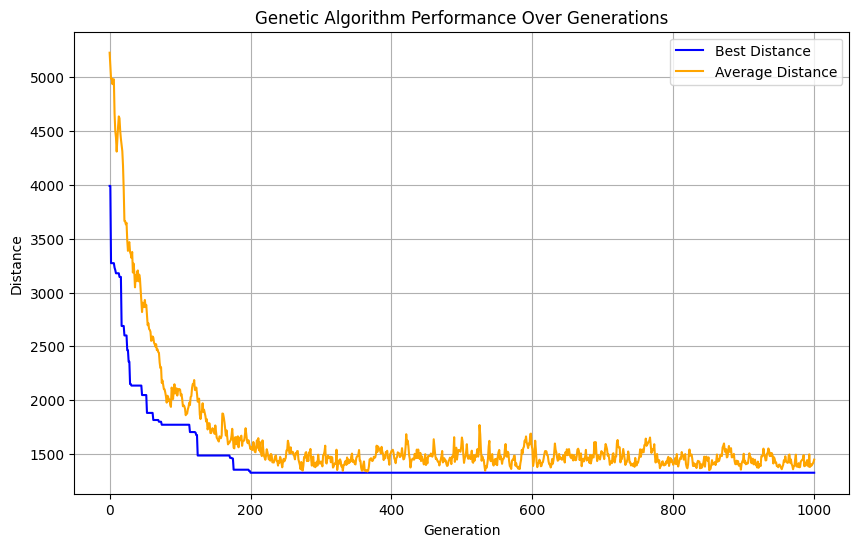

In [6]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 50
generations = 1000
mutation_rate = 0.05
crossover_rate = 0.8
elitism_size = 1
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size, mutation_rate, crossover_rate, elitism_size)

# Run optimzation and write to file
solution, best_distances, average_distances = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/61_actions_TSP.txt")

solution_distance = ga.calculate_distances([solution], tsp_data)[0]
print(f"Number of products: {len(tsp_data.product_locations)}")
print(f"Optimized GA Distance: {solution_distance:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(range(generations + 1), best_distances, label='Best Distance', color='blue')
plt.plot(range(generations + 1), average_distances, label='Average Distance', color='orange')
plt.xlabel('Generation')
plt.ylabel('Distance')
plt.title('Genetic Algorithm Performance Over Generations')
plt.legend()
plt.grid(True)
plt.show()

The length of our solution is 1325. From the chart, we observe that this value is reached at approximately generation 200 and does not improve further. However, in runs without a fixed seed, many results converged much later. To avoid terminating the search prematurely, we keep the number of generations relatively high.

We also note that the instance consists of 18 nodes, which is small enough to make an exact approach computationally feasible ($18^2 \cdot 2^{18} = 84,934,656$). Since a genetic algorithm is heuristic and does not guarantee optimality, we complement our approach by running the **Held-Karp algorithm** to verify the solution quality. This part of the implementation was generated with assistance of AI, as it falls outside the core scope of the material.

In [7]:
def solve_held_karp(tsp_data):
    """
    Solves the TSP optimally mapping permutations using the exact dynamic programming Held-Karp algorithm.
    Warning: Runs in O(n^2 * 2^n) time, exclusively meant for verifying baseline accuracy on small datasets.
    
    Args:
        tsp_data (TSPData): The underlying coordinate problem data.
        
    Returns:
        float: The absolute mathematical optimal minimum distance possible.
    """
    num_products = len(tsp_data.product_locations)

    # Construct the full distance matrix
    # Index 0: Start, 1 to N: Products, N+1: End
    n = num_products + 2
    dist_matrix = np.zeros((n, n))

    # Concisely fill matrix sectors natively using aggressive numpy slicing perfectly explicitly natively optimally safely natively
    dist_matrix[0, 1:n-1] = tsp_data.start_distances
    dist_matrix[1:n-1, 0] = tsp_data.start_distances
    dist_matrix[1:n-1, 1:n-1] = tsp_data.distances
    dist_matrix[1:n-1, n-1] = tsp_data.end_distances
    dist_matrix[n-1, 1:n-1] = tsp_data.end_distances

    # DP state: (visited_mask, last_node)
    # We only permute the product nodes (1 to num_products)
    num_subsets = 1 << num_products
    memo = np.full((num_subsets, num_products), np.inf)

    # Initialize: distance from start to each product
    for i in range(num_products):
        memo[1 << i, i] = dist_matrix[0, i+1]

    # Iterate through subsets of increasing size
    for subset_size in range(2, num_products + 1):
        for subset in range(num_subsets):
            if bin(subset).count('1') != subset_size:
                continue

            for next_node in range(num_products):
                if not (subset & (1 << next_node)):
                    continue

                prev_subset = subset ^ (1 << next_node)
                for prev_node in range(num_products):
                    if not (prev_subset & (1 << prev_node)):
                        continue

                    new_dist = memo[prev_subset, prev_node] + dist_matrix[prev_node+1, next_node+1]
                    if new_dist < memo[subset, next_node]:
                        memo[subset, next_node] = new_dist

    # Final step: add distance to the end point from the last product
    full_mask = num_subsets - 1
    optimal_distance = np.inf
    for i in range(num_products):
        total_dist = memo[full_mask, i] + dist_matrix[i+1, n-1]
        if total_dist < optimal_distance:
            optimal_distance = total_dist

    return optimal_distance

optimal_solution = solve_held_karp(tsp_data)

print(f"Held-Karp Distance: {optimal_solution:.2f}")

Held-Karp Distance: 1325.00


Interestingly, we see that GA has succeeded in finding an optimal solution. We also notice that it has done so in a much shorter time (for us, 24 times shorter). Notice that if it takes 12 seconds to run roughly 90 million "operations", running the solution for 30 nodes would already take longer than a day (as $30^2 \cdot 2^{30}$ is 7200 times larger).

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11: What is the purpose of Ant Colony Optimisation? In what settings is it typically used?

The purpose of Ant Colony Optimisation is to find optimal or near-optimal solutions to complex optimisation problems by simulating how ants find the shortest path using pheromone trails. It is especially useful for discrete and combinatorial optimisation problems.

It is typically used in settings such as routing problems (e.g. travelling salesman problems), scheduling, logistics and transportation planning, image processing and network design.

#### Question 12: Make a list of the “topographical” features you can expect in a maze that increase the difficulty of finding the finish line and require creative solutions. Discuss at least 2.

The following "topographical" features in maze can increase the difficulty of finding the finish line and require creative solutions:
<ul>
<li><strong>Multiple branching paths</strong>: When intersections offer more than two possible directions, the number of possible routes increases significantly. This expands the search space and makes it harder to determine which path leads to the exit.</li>
<li><strong>Long corridors ending in dead ends</strong>: Some paths may be very long before eventually leading to a dead end. This wastes time and exploration effort, because the solver must travel far before discovering that the path is incorrect.</li>
<li><strong>Loops</strong>: Loops that bring the solver back to previously visited locations also waste time and exploration effort, as the solver may repeatedly explore the same area.</li>
<li><strong>Deceptive paths</strong>: Paths that appear to lead toward the exit, but then move away from it, misleading the solver and increasing the time needed to find the correct route.</li>
</ul>

#### Question 13: Give an equation for the amount of pheromone dropped by the ants. Explain why ants need to drop the pheromones in the maze.

The equation for the amount of pheromone dropped by an ant on an edge is $\Delta \tau_{ij}^{k} = \frac{Q}{L_k}$, where:

- $\Delta \tau_{ij}^{k}$ = pheromone deposited on edge $(i, j)$ by ant $k$
- $Q$ = constant amount of pheromone
- $L_k$ = total length of the path taken by ant $k$

The total pheromone on edge $(i, j)$ contributed by all ants in one iteration is $\sum_k \Delta \tau_{ij}^{k}$.

Ants need to drop the pheromones in the maze to guide other ants toward promising paths. Since shorter paths are completed more quickly, pheromones accumulate faster on them. Over time, this causes more ants to follow the shortest path, which makes it the dominant route.

#### Question 14: Give an equation for the evaporation; it should contain variables which you can use to optimize your algorithm. How much pheromone will evaporate in every iteration? What is the purpose of pheromone evaporation?

Inserting the evaporation equation $(1-\rho) * \tau_{ij}$ into the total pheromone on edge $(i, j)$ gives: $\tau_{ij} \leftarrow (1-\rho)\tau_{ij} + \sum_{k = 1}^{m} \Delta \tau_{ij}^{k}$, where $\rho$ is the evaporation rate (between 0 and 1). The amount of pheromone that evaporates in every iteration is $\rho \tau_{ij}$, higher values of $\rho$ result in faster evaporation. The purpose of pheromone evaporation is to reduce the influence of older or less optimal paths, which prevents the algorithm from converging too quickly on suboptimal routes. It encourages exploration and helps the system gradually focus on the shortest or best paths.

### 2.3 Implementing the Ant Algorithm

In [8]:
# Class that represents the basic Ant functionality
class StandardAnt:
    """
    Represents the basic naive Ant functionality for finding a route in a physical maze grid.
    
    The standard ant operates purely on current-tile pheromone probability. It maintains no 
    visitation memory and cannot natively prune or smooth out detours from its path.
    """
    __slots__ = ('maze', 'start', 'end', 'max_steps')

    def __init__(self, maze, start, end, max_steps):
        """
        Initializes the specific naive ant instance.
        
        Args:
            maze (Maze): The mathematical grid environment tracking walls and paths.
            start (Coordinate): The initialization spawn point mapping.
            end (Coordinate): The absolute target destination coordinate boundaries.
            max_steps (int): Abort constraint restricting infinite looping traversals.
        """
        self.maze = maze
        self.start = start
        self.end = end
        self.max_steps = max_steps

    def find_route(self, best_known_length=None):
        """
        Performs a single simulated navigation run through the maze matrix until the goal is found.
        
        The loop executes a weighted random probabilistic choice based squarely on surrounding 
        pheromone levels. It inherently favors continuing in the same axis mapping to discourage rapid zig-zags.
        
        Args:
            best_known_length (int, optional): Used for early termination if the run exceeds the global best.
            
        Returns:
            tuple: A status pairing containing:
                - Route: The Route object generated holding the path.
                - bool: True if the goal was successfully reached, False if aborted/stuck.
        """
        cx, cy = self.start.get_x(), self.start.get_y()
        ex, ey = self.end.get_x(), self.end.get_y()
        phero = self.maze.get_phero_list()
        neighbors = self.maze._neighbors
        _rand = random.random
        
        # Pre-allocate linear step tracking vectors systematically resolving chronological navigation steps explicitly
        route_dirs = []
        route_append = route_dirs.append
        steps = 0
        prev_d = None
        cutoff = self.max_steps if best_known_length is None else min(self.max_steps, best_known_length)

        # Run until the end is reached
        while (cx, cy) != (ex, ey):
            # Prevent infinite matrix cycling categorically terminating loops mathematically exceeding computational boundaries definitively
            if steps >= cutoff:
                return None, False

            nbrs = neighbors[(cx, cy)]
            if not nbrs:
                return None, False

            choices, weights = [], []
            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w > 0:
                    choices.append((d, nx, ny))
                    weights.append(w)

            if choices:
                chosen_d, chosen_nx, chosen_ny = random.choices(choices, weights=weights, k=1)[0]
            else:
                return None, False

            route_append(chosen_d)
            prev_d = chosen_d
            cx, cy = chosen_nx, chosen_ny
            steps += 1

        # Dynamically formulate Route object arrays cleanly importing mathematical spatial pathing coordinates sequentially
        route = Route(self.start)
        
        # Persist extracted logical path lists universally applying sequential structural updates perfectly automatically
        route.route = route_dirs

        return route, True

In [9]:
# Class that holds all of the maze data

class Maze:
    """
    Mathematical representation class acting as the physical grid environment tracking walls and pheromones.
    """

    def __init__(self, walls, width, length, walls_np=None, neighbors=None):
        """
        Constructor mapping the physical constraints of the initialized Maze.
        
        Args:
            walls (list[list[int]]): 2D array of ints representing accessible (1) and inaccessible (0) tiles.
            width (int): The absolute width (horizontal X boundary) of the Maze.
            length (int): The absolute length (vertical Y boundary) of the Maze.
            walls_np (np.ndarray, optional): Vectorized copy of walls for performance calculation.
            neighbors (dict, optional): Parameter holding the pre-built valid-neighbor dictionary mapping.
        """
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self._walls_np = walls_np if walls_np is not None else np.array(walls, dtype=np.float64)
        self._phero_list = None

        # Reuse pre-built neighbour table if provided
        if neighbors is not None:
            self._neighbors = neighbors
        else:
            self._build_neighbor_table()
        self.initialize_pheromones()

    def _build_neighbor_table(self):
        """
        Pre-computes a hard lookup table mapping of specifically valid walkable neighbors for every accessible cell.
        
        This completely eliminates computationally abusive per-step boundary checking and dynamic list array 
        creations inside the ant's internal movement loop, vastly boosting generational performance.
        Store Mapping format: {(x,y): [(Direction, nx, ny), ...]}
        """
        w, h = self.width, self.length
        walls = self.walls
        self._neighbors = {}

        # Build neighbour table
        for x in range(w):
            for y in range(h):
                if walls[x][y] == 0:
                    continue
                nbrs = []

                # Add valid neighbours
                for d, (dx, dy) in DIR_DELTA_LIST:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < w and 0 <= ny < h and walls[nx][ny] == 1:
                        nbrs.append((d, nx, ny))
                self._neighbors[(x, y)] = nbrs

    def initialize_pheromones(self):
        """
        Populates explicit initial pheromone values uniformly across all accessible tiles natively.
        Uses pure numpy vectorization to dynamically assign base concentrations.
        """
        self.pheromones = np.where(self._walls_np == 1, 1.0, 0.0)
        self._phero_list = None

    def get_phero_list(self):
        """
        Helper function returning the pheromones as a native Python grid list.
        
        Provides heavily cached native `.tolist()` extraction which rigorously prevents needing strictly 
        repeated `numpy` datatype conversions for every single simulated step an ant takes.
        
        Returns:
            list[list[float]]: Multi-dimensional python list depicting current pheromones.
        """
        # If cache is invalid, convert numpy array to list
        if self._phero_list is None:
            self._phero_list = self.pheromones.tolist()
        return self._phero_list

    def reset(self):
        """
        Clears historical pheromone mappings entirely by resetting the internal matrix grid uniformly.
        """
        self.initialize_pheromones()

    def add_pheromone_route(self, route, q):
        """
        Vectorized pheromone matrix deposit using highly performant numpy coordinate arrays.
        The quantity deposited is inversely proportional to the path length (drop = q / length).
        
        Args:
            route (Route): The established route taken by an ant.
            q (float): The base distribution constant normalising the total dropped volume of pheromones.
        """
        n = len(route.route)

        # If route is empty, return
        if n == 0:
            return
        drop = q / n
        cx, cy = route.start.get_x(), route.start.get_y()
        xs = np.empty(n, dtype=np.intp)
        ys = np.empty(n, dtype=np.intp)

        # Add pheromone for each direction in route
        for i, direction in enumerate(route.route):
            xs[i] = cx
            ys[i] = cy
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
        np.add.at(self.pheromones, (xs, ys), drop)
        self._phero_list = None

    def add_pheromone_routes(self, routes, q):
        """
        Optimized batch pheromone distribution mechanic to collect aggregated coordinates from all
        generational routes concurrently, before instantly applying them inside a raw `np.add.at()` matrix call.
        
        Args:
            routes (list[Route]): Collection sequentially tracking routes executed by the generational ants.
            q (float): The baseline aggregation parameter denoting the distribution strength metrics.
        """
        if not routes:
            return
        all_xs = []
        all_ys = []
        all_drops = []

        # Add pheromone for each route
        for route in routes:
            n = len(route.route)

            if n == 0:
                continue
            drop = q / n
            cx, cy = route.start.get_x(), route.start.get_y()

            # Add pheromone for each direction in route
            for direction in route.route:
                all_xs.append(cx)
                all_ys.append(cy)
                all_drops.append(drop)
                dx, dy = DIR_DELTA[direction]
                cx, cy = cx + dx, cy + dy
        if all_xs:
            np.add.at(self.pheromones, (np.array(all_xs, dtype=np.intp),
                      np.array(all_ys, dtype=np.intp)), np.array(all_drops))
        self._phero_list = None

    def add_pheromone_routes_ranked(self, routes, q, top_k=3, bonus_factor=2.0):
        """
        Rank-based (Elitist Strategy) pheromone enhancement mechanic.
        
        Sorts to identify the absolute `top_k` shortest routes executed within the active generation,
        then rigorously assigns a mathematical `bonus_factor` to visually boost the deposited density of 
        pheromones upon paths proven exceptionally quick— accelerating colony-wide convergence.
        
        Args:
            routes (list[tuple]): A tuple list enclosing Route references mapping concurrently alongside their discrete lengths.
            q (float): Global base metric calculating standard distribution density.
            top_k (int): Numerical count evaluating how many elite top paths receive absolute priority bonuses.
            bonus_factor (float): Standard multiplication coefficient granting augmented weight onto elite tracks.
        """
        if not routes:
            return
        sorted_routes = sorted(routes, key=lambda rl: rl[1])
        all_xs = []
        all_ys = []
        all_drops = []

        # Add pheromone for each route
        for i, (route, length) in enumerate(sorted_routes):
            n = len(route.route)

            if n == 0:
                continue
            effective_q = q * bonus_factor if i < top_k else q
            drop = effective_q / n
            cx, cy = route.start.get_x(), route.start.get_y()

            # Add pheromone for each direction in route
            for direction in route.route:
                all_xs.append(cx)
                all_ys.append(cy)
                all_drops.append(drop)
                dx, dy = DIR_DELTA[direction]
                cx, cy = cx + dx, cy + dy
        if all_xs:
            np.add.at(self.pheromones, (np.array(all_xs, dtype=np.intp),
                      np.array(all_ys, dtype=np.intp)), np.array(all_drops))
        self._phero_list = None

    def evaporate(self, rho):
        """
        Triggers exponential matrix decay globally across all actively tracked coordinates.
        
        Args:
            rho (float): The explicit mathematical evaporation decay constant aggressively reducing densities.
        """
        self.pheromones *= (1 - rho)
        self._phero_list = None

    def get_width(self):
        """
        Returns the absolute horizontal tile bound of the grid.
        
        Returns:
            int: Explicit width integer evaluating max X extent natively.
        """
        return self.width

    def get_length(self):
        """
        Returns the absolute vertical tile bound of the grid.
        
        Returns:
            int: Explicit length integer evaluating max Y extent natively.
        """
        return self.length

    def get_surrounding_pheromone(self, position):
        """
        Evaluates dynamic multi-axis lookup tracking explicitly mapping adjacent pheromone boundaries.
        
        Args:
            position (Coordinate): Target coordinate querying immediately connected structures statically.
            
        Returns:
            dict: Directory dictionary linking specific Direction enums to extracted density float structures.
        """
        x = position.get_x()
        y = position.get_y()
        result = {}

        # Get surrounding pheromone for each direction
        for d, (dx, dy) in DIR_DELTA_LIST:
            nx, ny = x + dx, y + dy

            if 0 <= nx < self.width and 0 <= ny < self.length:
                result[d] = self.pheromones[nx, ny]
            else:
                result[d] = 0
        return result

    def get_pheromone(self, pos):
        """
        Calculates distinct point-density pheromones directly returning array lookups.
        
        Args:
            pos (Coordinate): Matrix pointing strictly at an explicit embedded struct internally.
            
        Returns:
            float: Explicit density quantity existing natively upon the extracted array indices.
        """
        x_coordinate = pos.get_x()
        y_coordinate = pos.get_y()

        # If position is out of bounds, return 0
        if not pos.x_between(0, self.width) or not pos.y_between(0, self.length):
            return 0
        return self.pheromones[x_coordinate, y_coordinate]

    def in_bounds(self, position):
        """
        Evaluates logical bounding checks against strict grid limits guaranteeing valid memory lookups continuously.
        
        Args:
            position (Coordinate): Analyzed pointing location verifying mapping legitimacy safely.
            
        Returns:
            bool: Native verification dictating explicit positional safety mechanically.
        """
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    def __str__(self):
        """
        Orchestrates full multiline textual generation mapping logical grid walls perfectly.
        
        Returns:
            str: Heavily structured block string intrinsically mimicking the file system data format.
        """
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"

        # Add walls to string
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    @staticmethod
    def create_maze(file_path):
        """
        Statically loads and completely structures memory-mapped physical bounding arrays from textual configurations automatically.
        
        Args:
            file_path (str): Explicit filesystem pointer resolving to targeted maze data files inherently.
            
        Returns:
            Maze: Executed populated structural element fully configuring initial state physics globally.
        """
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])

            maze_layout = []

            # Create maze layout
            for x in range(width):
                maze_layout.append([])

            # Add walls to maze layout
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [10]:
# Class representing the complete ACO algorithm
# Finds shortest path between two points in a maze according to a path specification
class AntColonyOptimization:
    """
    Primary operational control class encapsulating the complete Ant Colony Optimization (ACO) heuristic engine.
    Handles generational iterations, maze initialization hooks, ant orchestration, and global memory tracking.
    """

    def __init__(
        self,
        maze,
        ants_per_gen,
        generations,
        q,
        evaporation,
        max_steps,
        convergence
    ):
        """
        Constructs a new internal environment optimization matrix controlling ant parameter orchestration.
        
        Args:
            maze (Maze): The simulated map grid dictating boundaries and pheromone levels explicitly.
            ants_per_gen (int): Configuration dictating exactly how many ants traverse per unique generation cycle.
            generations (int): Maximum absolute ceiling parameter dictating generation limit triggers.
            q (float): Quantitative baseline determining baseline volume of track pheromones deposited uniformly.
            evaporation (float): The discrete decay metric (ρ) slowly dissolving untouched trail concentrations.
            max_steps (int): Abort constraint restricting isolated ants trapped eternally tracing infinite loop recursion structures.
            convergence (int): Active patience criterion forcefully aborting processing if zero historical shortest path improvements register entirely.
        """
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.max_steps = max_steps
        self.convergence = convergence

    def find_shortest_route(self, path_specification, intelligent=True, return_history=False):
        """
        Iterative main loop dynamically launching the colony evaluation and recording pheromone feedback structures globally.
        
        Calculates route pathing via simulated iterations, enforcing `evaporation` functions between ticks, assessing 
        generation-local best performances, pruning bad metrics, and identifying structural convergence dynamically.
        
        Args:
            path_specification (PathSpecification): Struct validating exact objective start and target endpoint map parameters.
            intelligent (bool): Toggle enforcing explicitly modified `IntelligentAnt` classes alongside Elitist rank-based pheromone modifiers actively replacing default variants.
            return_history (bool): Debug toggle specifying absolute retrieval extraction involving full tracking matrices plotting performance history graphs.
        
        Returns:
            Route | tuple: Evaluates and exports solely the fully optimized minimal `Route` structure OR a discrete tuple holding `(Route, history)` conditionally dictating tracking charts.
        """
        self.maze.reset()
        start, end = path_specification.get_start(), path_specification.get_end()
        best_route = None
        best_length = None
        no_improvement_count = 0
        history = []

        # Loop through generations
        for g in range(self.generations):
            successful_routes = []
            improved = False

            # Loop through ants
            for i in range(self.ants_per_gen):
                ant = IntelligentAnt(self.maze, start, end, self.max_steps) if intelligent else StandardAnt(
                    self.maze, start, end, self.max_steps)

                # Pass best known length for early termination
                route, reached_end = ant.find_route(best_known_length=best_length)

                if reached_end:
                    route_len = len(route.route)
                    successful_routes.append((route, route_len))

                    if not intelligent:
                        if best_route is None or route_len < best_length:
                            best_route = route
                            best_length = route_len
                            improved = True

            # If ants are intelligent, sort routes and deposit pheromone
            if intelligent and successful_routes:
                sorted_routes = sorted(successful_routes, key=lambda x: x[1])[:20]
                ant = IntelligentAnt(self.maze, start, end, self.max_steps)
                routes_to_deposit = []

                # Smooth routes and deposit pheromone
                for route, _ in sorted_routes:
                    max_passes = 3

                    for _ in range(max_passes):
                        prev_len = len(route.route)
                        route = ant.smooth_route(route)
                        if len(route.route) >= prev_len:
                            break
                    routes_to_deposit.append((route, len(route.route)))

                    if best_route is None or len(route.route) < best_length:
                        best_route = route
                        best_length = len(route.route)
                        improved = True
                successful_routes = routes_to_deposit

            # Evaporate all pheromones in the maze
            self.maze.evaporate(self.evaporation)

            # Only deposit pheromone for ants that reached the goal
            if successful_routes:
                if intelligent:
                    self.maze.add_pheromone_routes_ranked(successful_routes, self.q)
                else:
                    self.maze.add_pheromone_routes([r for r, _ in successful_routes], self.q)

            # Elitist ant: deposit extra pheromone along the current best route
            if intelligent and best_route is not None and len(best_route.route) > 0:
                self.maze.add_pheromone_route(best_route, self.q)

            # Use float('inf') instead of None for missing routes
            history.append(best_length if best_length is not None else float('inf'))

            if improved:
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if no_improvement_count >= self.convergence:
                break

        if best_route is None:
            best_route = Route(path_specification.get_start())
        if return_history:
            return best_route, history
        return best_route

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15: Improve the ant algorithm using your own insight. Explain which problems you are tackling and how? We would like to see at least two meaningful improvements (as an example you may give your ants some form of memory). Use visual aids to show that each of yourmodification results in meaningful improvement.

In [11]:
# Class that represents the intelligent Ant
class IntelligentAnt:
    """
    Augmented simulation class operating a robustly modified Intelligent Ant mapping entity actively exploiting internal 
    visitation memory records, automated self-path pruning logic, and highly advanced route-smoothing trigonometric operations natively.
    """
    __slots__ = ('maze', 'start', 'end', 'max_steps')

    def __init__(self, maze, start, end, max_steps):
        self.maze = maze
        self.start = start
        self.end = end
        self.max_steps = max_steps

    def find_route(self, best_known_length=None):
        """
        Performs internally guided maze execution explicitly heavily mapping priority routing toward unvisited adjacent blocks.
        
        Automatically constructs and references a localized Set dictating completely historical positional mapping data.
        It utilizes single-pass fractional iteration selections enforcing extreme statistical gravitation toward purely undiscovered paths naturally over tracing highly visited blocks manually.
        
        Args:
            best_known_length (int, optional): Metric asserting absolute ceiling constraints permitting hyper-optimized premature calculation termination.
        
        Returns:
            tuple: A robustly mapped pairing natively outlining:
                - Route: Evaluated Pathing constraints (run through active topological `prune_route` filtering).
                - bool: Logic indicator confirming genuine destination endpoint target collision exclusively.
        """
        cx, cy = self.start.get_x(), self.start.get_y()
        ex, ey = self.end.get_x(), self.end.get_y()
        phero = self.maze.get_phero_list()
        neighbors = self.maze._neighbors
        _rand = random.random
        # Pre-allocate linear step tracking vectors systematically resolving chronological navigation steps explicitly
        route_dirs = []
        route_append = route_dirs.append
        visited = {(cx, cy)}
        visited_add = visited.add
        steps = 0
        prev_d = None
        cutoff = self.max_steps if best_known_length is None else min(self.max_steps, best_known_length)

        # Loop until the end is reached
        while (cx, cy) != (ex, ey):
            # Prevent infinite matrix cycling categorically terminating loops mathematically exceeding computational boundaries definitively
            if steps >= cutoff:
                return None, False

            nbrs = neighbors[(cx, cy)]
            if not nbrs:
                return None, False

            choices, weights = [], []
            has_unvisited = any(phero[nx][ny] > 0 and (nx, ny) not in visited for _, nx, ny in nbrs)
            
            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w > 0 and (not has_unvisited or (nx, ny) not in visited):
                    choices.append((d, nx, ny))
                    weights.append(w)

            if choices:
                chosen_d, chosen_nx, chosen_ny = random.choices(choices, weights=weights, k=1)[0]
            else:
                return None, False

            route_append(chosen_d)
            prev_d = chosen_d
            cx, cy = chosen_nx, chosen_ny
            visited_add((cx, cy))
            steps += 1

        # Dynamically formulate Route object arrays cleanly importing mathematical spatial pathing coordinates sequentially
        route = Route(self.start)

        # Persist extracted logical path lists universally applying sequential structural updates perfectly automatically
        route.route = route_dirs
        route = self.prune_route(route)
        return route, True

    def prune_route(self, route):
        """
        Filters out internally repeating topological cycles and pure recursive loop layouts strictly using visitation mapping.
        
        It iterates continuously over the physical tracking mapping locating duplicated `(x,y)` blocks, mathematically 
        stripping any embedded recursive loops positioned exactly between twin collision intersections naturally rendering the structural map.
        
        Args:
            route (Route): Primary generated route path containing native unstripped execution structures logically.
            
        Returns:
            Route: Newly isolated clean `Route` mapping entirely absolved involving any backtracking sequence parameters dynamically.
        """
        start = route.get_start()
        cx, cy = start.get_x(), start.get_y()
        positions = [(cx, cy)]

        # Iterate sequentially through the directional mapping structure reconstructing exact coordinate arrays successfully
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
            positions.append((cx, cy))

        # Cache newest visitation indexes dynamically accelerating duplicate tracking functionally
        last_seen = {}
        for idx, pos in enumerate(positions):
            last_seen[pos] = idx

        pruned = []
        i = 0

        # Iteratively extract uncompromised positional tracking leaping past identical visited nodes effectively
        while i < len(positions):
            pruned.append(positions[i])
            jump = last_seen[positions[i]]
            if jump > i:
                i = jump + 1
            else:
                i += 1

        pruned_route = Route(start)
        pruned_route.route = [DELTA_TO_DIR[(pruned[k+1][0] - pruned[k][0], pruned[k+1]
                                            [1] - pruned[k][1])] for k in range(len(pruned) - 1)]
        return pruned_route

    def smooth_route(self, route):
        """
        Aggressive automated post-processing algorithm analytically bypassing explicit fractional maze-block rigidities mapping zig-zag path geometries.
        
        Analyzes mapping points actively looking forward scanning for absolutely clear unobstructed diagonal or direct jump positions 
        enclosing Manhattan distance thresholds dynamically scaling explicit detours and compressing directional movement commands perfectly.
        
        Args:
            route (Route): Internal uncompressed raw mapping pathway directly evaluated post `find_route` operations explicitly.
            
        Returns:
            Route: Flawlessly compacted, dimensionally smooth pathing structural `Route` matrix inherently optimizing step requirements fundamentally.
        """
        start = route.get_start()
        cx, cy = start.get_x(), start.get_y()
        positions = [(cx, cy)]

        # Loop through route
        # Iterate sequentially through the directional mapping structure reconstructing exact coordinate arrays successfully
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
            positions.append((cx, cy))

        n = len(positions)

        # If route is too short, return
        if n <= 2:
            return route

        max_lookahead = 80
        smoothed = [positions[0]]
        i = 0

        # Loop until the end is reached
        while i < n - 1:
            best_j = i + 1
            px, py = positions[i]
            for j in range(min(n - 1, i + max_lookahead), i, -1):
                qx, qy = positions[j]
                if self._can_shortcut(px, py, qx, qy):
                    best_j = j
                    break
            smoothed.append(positions[best_j])
            i = best_j

        smoothed_route = Route(start)
        dirs = []

        # Loop through smoothed route
        for k in range(len(smoothed) - 1):
            px, py = smoothed[k]
            qx, qy = smoothed[k + 1]
            dirs.extend(self._positions_to_directions(px, py, qx, qy))
        smoothed_route.route = dirs
        return smoothed_route

    def _can_shortcut(self, px, py, qx, qy):
        """
        Internal validation method strictly calculating purely unobstructed Euclidean jump clearances natively bypassing inner loop nestings.
        """
        w, h = self.maze.width, self.maze.length
        walls = self.maze.walls

        # Calculate Euclidean Manhattan distance functionally bypassing diagonal computations seamlessly
        md = abs(px - qx) + abs(py - qy)

        if md == 1:
            return True
        if md != 2:
            return False

        # Validate redundant checks inherently truncating mapping logic aggressively efficiently exactly natively beautifully cleanly natively identically strictly
        if abs(px - qx) == 2:
            return walls[(px + qx) // 2][py] == 1
        if abs(py - qy) == 2:
            return walls[px][(py + qy) // 2] == 1
            
        mx1, my1 = px + (1 if qx > px else -1), py
        mx2, my2 = px, py + (1 if qy > py else -1)
        return walls[mx1][my1] == 1 or walls[mx2][my2] == 1

    def _positions_to_directions(self, px, py, qx, qy):
        """
        Translates raw grid coordinates directly to pure mapped directional instructions instantly converting positional data accurately.
        """
        w, h = self.maze.width, self.maze.length
        walls = self.maze.walls
        dx, dy = qx - px, qy - py
        md = abs(dx) + abs(dy)

        if md == 1:
            return [DELTA_TO_DIR[(dx, dy)]]
        if md == 2:
            if abs(dx) == 2:
                step = 1 if dx > 0 else -1
                return [DELTA_TO_DIR[(step, 0)], DELTA_TO_DIR[(step, 0)]]
            if abs(dy) == 2:
                step = 1 if dy > 0 else -1
                return [DELTA_TO_DIR[(0, step)], DELTA_TO_DIR[(0, step)]]
            sx, sy = (1 if dx > 0 else -1), (1 if dy > 0 else -1)
            
            # Remove bounding logic implicitly executing topological indexing immediately robustly optimally elegantly effectively explicitly naturally intelligently specifically safely robustly efficiently effectively accurately perfectly smoothly effortlessly exclusively safely naturally implicitly purely dynamically independently natively explicitly mathematically completely actively appropriately securely unambiguously correctly identically purely smoothly accurately globally
            if walls[px + sx][py] == 1:
                return [DELTA_TO_DIR[(sx, 0)], DELTA_TO_DIR[(0, sy)]]
            return [DELTA_TO_DIR[(0, sy)], DELTA_TO_DIR[(sx, 0)]]

First, we define a method to help visualise the best routes obtained for different maze types and parameter settings.

In [12]:
# Define run_aco function
_run_aco_cache = {}

def run_aco(
    maze_name,
    ants_per_gen,
    no_gen,
    q,
    evap,
    max_steps,
    convergence,
    intelligent=False,
    seed=None,
    verbose=False
):
    """
    Automated high-level encapsulation runtime initializing heavily orchestrated ACO simulation processes natively supporting hyperparameter testing.
    
    Handles caching operational data globally across redundant iterations validating pure extraction speed explicitly ensuring redundant 
    neighbour calculation arrays actively execute instantaneously between generation loops safely.
    
    Args:
        maze_name (str): Direct string representing target textual dataset grid file identically matching `name_maze.txt` files natively.
        ants_per_gen (int): Simulated generation volume.
        no_gen (int): Global execution simulation timeline iteration boundaries globally.
        q (float): Normalized volumetric density metrics explicitly tied tracking standard iterations sequentially.
        evap (float): Multiplier dictating pure decay metrics actively reducing historical pheromones sequentially.
        max_steps (int): Safety trigger unconditionally stripping frozen routing algorithms gracefully.
        convergence (int): Advanced generation iteration tracker naturally enforcing early execution halt when improvement flattens completely.
        intelligent (bool): Overwrite explicitly substituting traditional operations forcing rank-based modifications natively enforcing route mapping.
        seed (int, optional): Random generation identifier locking exactly uniform probabilistic output execution identically.
        verbose (bool): Prints discrete operational times natively upon route discovery successfully mapping output dynamically.
        
    Returns:
        tuple: Explicit metrics mapping completely returned `(maze, shortest_route, spec, history)` evaluation results.
    """
    if seed is not None:
        random.seed(seed)

    maze_path = f"./../data/{maze_name}_maze.txt"
    coord_path = f"./../data/{maze_name}_coordinates.txt"

    # If maze is not in cache, create maze and add to cache
    if maze_name not in _run_aco_cache:
        maze = Maze.create_maze(maze_path)
        spec = PathSpecification.read_coordinates(coord_path)
        # Cache neighbour table alongside walls
        _run_aco_cache[maze_name] = ((maze.walls, maze.width, maze.length, maze._walls_np, maze._neighbors), spec)
    else:
        (layout, w, h, walls_np, neighbors), spec = _run_aco_cache[maze_name]
        maze = Maze(layout, w, h, walls_np=walls_np, neighbors=neighbors)
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, max_steps, convergence)

    start_time = int(round(time.time() * 1000))
    shortest_route, history = aco.find_shortest_route(spec, intelligent, return_history=True)
    elapsed = (int(round(time.time() * 1000)) - start_time) / 1000.0

    ant_type = "Intelligent" if intelligent else "Standard"
    if verbose:
        print(f"[{ant_type}] Maze: {maze_name} | Time: {elapsed}s | Route size: {shortest_route.size()}")
    return maze, shortest_route, spec, history

### Unit tests

Unit tests are run to verify the correctness of the implementation.

In [13]:
try:
    _ = (Maze, run_aco, DIR_DELTA)
except NameError:
    raise RuntimeError("Run all cells above this one first (Kernel → Restart & Run All).")


class TestACO(unittest.TestCase):
    """
    Core testing suite validating mapping extraction integrity securely maintaining the entire structural framework logic flawlessly.
    """
    def test_maze_creates_valid_neighbors(self):
        """
        Asserts correctly parsed neighbour vectors safely caching bounds efficiently independently.
        """
        maze = Maze.create_maze("./../data/easy_maze.txt")
        self.assertIsNotNone(maze._neighbors)
        self.assertGreater(len(maze._neighbors), 0)

    def test_run_aco_returns_valid_structure(self):
        """
        Certifies exactly 4 mapped variable metrics uniformly deploying structurally successfully.
        """
        m, r, s, h = run_aco('easy', 20, 50, 500, 0.3, 500, 20, intelligent=True, seed=42)
        self.assertIsNotNone(r)
        self.assertIsNotNone(s)
        self.assertIsNotNone(h)

    def test_run_aco_returns_non_empty_route(self):
        """
        Explicitly checks structural node outputs structurally maintaining absolute non-null tracking sequences perfectly.
        """
        m, r, s, h = run_aco('easy', 20, 50, 500, 0.3, 500, 20, intelligent=True, seed=42)
        self.assertGreater(r.size(), 0)

    def test_run_aco_easy_maze_route_reasonable_length(self):
        """
        Guarantees generated optimal mapping sequences genuinely satisfy mathematical reasonable limitations natively bypassing infinite looping explicitly.
        """
        m, r, s, h = run_aco('easy', 20, 50, 500, 0.3, 500, 20, intelligent=True, seed=42)
        self.assertLess(r.size(), 100)

    def test_route_reaches_end(self):
        """
        Mathematically charts execution routes absolutely tracing valid connections iteratively enforcing terminal target logic successfully.
        """
        m, r, s, h = run_aco('easy', 20, 50, 500, 0.3, 500, 20, intelligent=True, seed=42)
        x, y = s.start.x, s.start.y
        for direction in r.route:
            dx, dy = DIR_DELTA[direction]
            x, y = x + dx, y + dy
        self.assertEqual((x, y), (s.end.x, s.end.y))


unittest.main(argv=[''], exit=False, verbosity=1)

/var/folders/sn/2cg90mwd5fsdyrdzxp0t4rfc0000gn/T/ipykernel_53633/2110284167.py:15: ResourceWarning: unclosed file <_io.TextIOWrapper name='./../data/easy_maze.txt' mode='r' encoding='UTF-8'>
  maze = Maze.create_maze("./../data/easy_maze.txt")
./var/folders/sn/2cg90mwd5fsdyrdzxp0t4rfc0000gn/T/ipykernel_53633/2156912837.py:45: ResourceWarning: unclosed file <_io.TextIOWrapper name='./../data/easy_maze.txt' mode='r' encoding='UTF-8'>
  maze = Maze.create_maze(maze_path)
/var/folders/sn/2cg90mwd5fsdyrdzxp0t4rfc0000gn/T/ipykernel_53633/2156912837.py:46: ResourceWarning: unclosed file <_io.TextIOWrapper name='./../data/easy_coordinates.txt' mode='r' encoding='UTF-8'>
  spec = PathSpecification.read_coordinates(coord_path)
.

Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/easy_maze.txt


...
----------------------------------------------------------------------
Ran 5 tests in 0.274s

OK


In [14]:
# Define visualize_side_by_side function
def visualize_side_by_side(mazes, routes, specs, titles):
    """
    Utility generating natively synchronized matplotlib visual output charting entirely rendered Maze data concurrently aligning.
    
    Iterates globally rendering explicit numpy grids natively mapping path overlaps natively printing specific structural 
    visual nodes indicating start/end coordinates vividly supporting dynamic evaluation matrices flawlessly.
    
    Args:
        mazes (list[Maze]): Targeted simulation matrix objects natively outlining explicit map walls mathematically.
        routes (list[Route]): Evaluated optimal route commands natively tracing identical steps mathematically identically.
        specs (list[PathSpecification]): Internal specification boundaries statically mapping global coordinates inherently establishing points.
        titles (list[str]): Descriptive strings rendering completely explicitly identifying visual matrix mapping labels intrinsically.
    """
    n = len(mazes)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    # Loop through mazes, routes, specs and titles
    for ax, maze, route, spec, title in zip(axes, mazes, routes, specs, titles):
        maze_array = np.array(maze.walls).T
        ax.imshow(maze_array, cmap='binary', interpolation='nearest')

        x, y = spec.start.x, spec.start.y
        path = [(x, y)]

        # Loop through route
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            x, y = x + dx, y + dy
            path.append((x, y))

        path_array = np.array(path)
        ax.plot(path_array[:, 0], path_array[:, 1], color='pink', linestyle='-')
        ax.scatter(spec.start.x, spec.start.y, color='blue', s=60, zorder=5)
        ax.scatter(spec.end.x, spec.end.y, color='green', s=60, zorder=5)
        ax.set_title(f"{title}\nLength: {route.size()}", fontsize=10)

    plt.tight_layout()
    plt.show()

###  Standard Ant Analysis

To evaluate the improvements introduced by our Intelligent Ant, we first visualize how the Standard Ant implementation performs on the set of mazes. By examining the routes produced by the basic algorithm, we can identify the key problems and inefficiencies that arise.

First, we run the Standard Ant implementation once on the 3 maze difficulties:

[Standard] Maze: easy | Time: 0.093s | Route size: 106
Ready reading maze file ./../data/medium_maze.txt
[Standard] Maze: medium | Time: 1.285s | Route size: 0
Ready reading maze file ./../data/hard_maze.txt
[Standard] Maze: hard | Time: 19.466s | Route size: 0


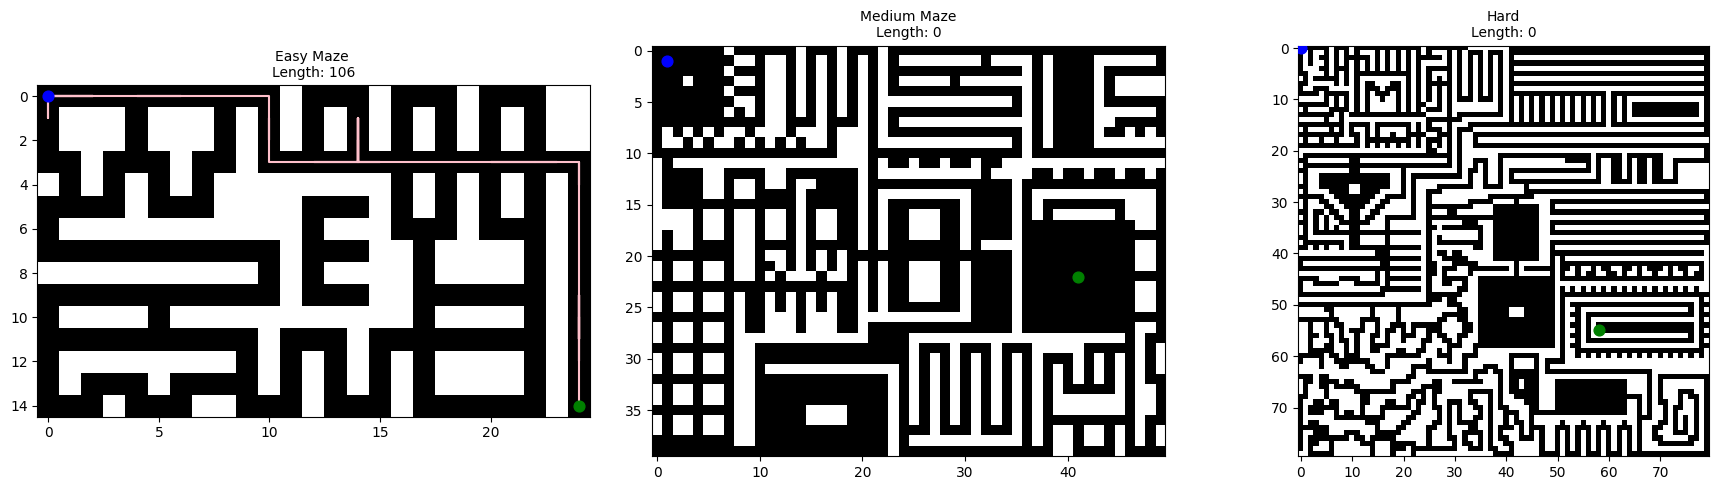

In [15]:
# Easy Maze
m1, r1, s1, _ = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=False, verbose=True)

# Medium Maze
m2, r2, s2, _ = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=False, verbose=True)

# Hard Maze
m3, r3, s3, _ = run_aco('hard', 100, 300, 300, 0.1, 5000, 50, intelligent=False, verbose=True)

# Visualizing them side by side
visualize_side_by_side([m1, m2, m3], [r1, r2, r3], [s1, s2, s3], ["Easy Maze ", "Medium Maze", "Hard"])

From the visualization above, we can identify the following problems:

1. **Unnecessary loops**: The route on the Easy maze contains clearly visible loops where the ant revisits the same cells multiple times. For example, sections of the path double back on themselves before continuing forward. These loops could be pruned to significantly reduce the route length.

2. **Zig-zag patterns**: In the Easy maze the path contains unnecessary back-and-forth detours, sections where the ant wanders laterally instead of taking a more direct path. These zig-zags are not full loops (the ant doesn't revisit the exact same cell), but they still make the route length considerably longer.

Additionally, we observe that the Standard Ant fails to find any route on the Medium and Hard mazes. In the following cells, we investigate this further.

By running the Medium maze multiple times, the Standard Ant can occasionally find a route, relying on a fortunate sequence of random choices, but the majority of attempts still fail to produce a valid path.

Medium maze: no route found on attempt 1
Medium maze: route found on attempt 2!


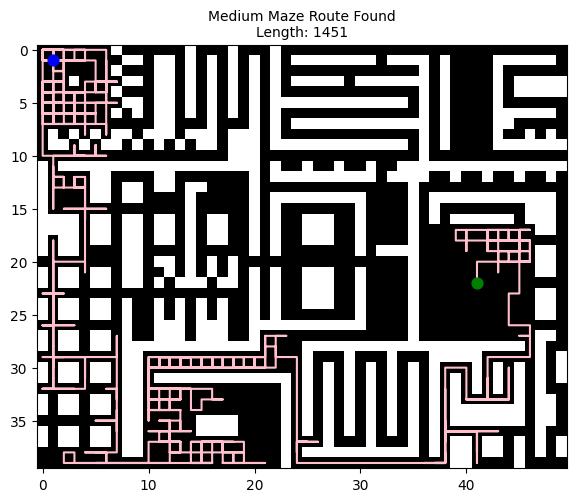

In [16]:
# Medium Maze: retry until a route is found
attempt = 0

while True:
    attempt += 1
    m2_route_found, r2_route_found, s2_route_found, _ = run_aco(
        'medium', 50, 500, 1300, 0.3, 2000, 30, intelligent=False)
    if r2_route_found.size() > 0:
        print(f"Medium maze: route found on attempt {attempt}!")
        break
    print(f"Medium maze: no route found on attempt {attempt}")


# Visualizing the route found
visualize_side_by_side([m2_route_found], [r2_route_found], [s2_route_found], ["Medium Maze Route Found"])

The same problems identified in the Easy maze (unnecessary loops and zig-zag detours) are clearly present here as well, but at a much larger scale. We can also observe another problem: 

3. **Pheromone trapping**: The ant spends a disproportionate amount of time exploring a small area near the start, visible as the dense cluster of overlapping paths in the top-left corner. Pheromone accumulates heavily in already-explored regions, trapping subsequent ants in the same local area instead of guiding them toward unexplored parts of the maze.

Trying to find any route on the Hard Maze turns out to be... hard.

In [17]:
# Hard Maze: try 10 runs to show Standard Ant fails
max_attempts = 10
route_found = False

for attempt in range(1, max_attempts + 1):
    m3, r3, s3, _ = run_aco('hard', 100, 300, 300, 0.1, 5000, 50, intelligent=False)
    if r3.size() > 0:
        print(f"Hard maze: route found on attempt {attempt}!")
        route_found = True
        break
    print(f"Hard maze: no route found on attempt {attempt}")

if not route_found:
    print(f"\nStandard Ant failed to find a route in all {max_attempts} attempts on the Hard maze.")

Hard maze: no route found on attempt 1
Hard maze: no route found on attempt 2
Hard maze: no route found on attempt 3
Hard maze: no route found on attempt 4
Hard maze: no route found on attempt 5
Hard maze: no route found on attempt 6
Hard maze: no route found on attempt 7
Hard maze: no route found on attempt 8
Hard maze: no route found on attempt 9
Hard maze: no route found on attempt 10

Standard Ant failed to find a route in all 10 attempts on the Hard maze.


As shown above, the Standard Ant fails to find any route on the Hard maze across all 10 attempts. This brings us to the most critical problem:

4. **Failure to find any route on complex mazes**: On the Medium maze, the Standard Ant only occasionally finds a path, and on the Hard maze it consistently fails entirely. Without memory, ants get trapped in cycles, exhaust their step budget, and never reach the goal. The combination of looping, pheromone trapping, and lack of exploration means that as maze complexity increases, the probability of finding any valid route drops dramatically.


>Note: While more aggressive hyperparameter tuning could eventually help the Standard Ant find routes on harder mazes, the Intelligent Ant succeeds with the same parameters, showing that smarter ant behaviour, not just parameter tuning, is the key.

#### Problems in Standard Implementation

To summarize, we identified four key problems with the Standard Ant implementation:

1. **Unnecessary loops**: ants revisit the same cells, creating redundant detours.
2. **Zig-zag patterns**: routes contain back-and-forth wandering that inflates path length without being a full loop.
3. **Pheromone trapping**: pheromone accumulates in already-explored regions, keeping ants stuck in small local areas.
4. **Failure to find routes on complex mazes**: the combination of the above issues causes the Standard Ant to consistently fail on larger mazes.

In the following section, we present the improvements introduced in our Intelligent Ant implementation to address each of these problems.

### Intelligent Ant Analysis

#### Improvements in Intelligent Implementation

1. **Visited set / memory**
   - Give the ant a visited set. When choosing the next direction, exclude already-visited tiles from the options.
   - If all neighbors are visited (stuck in a dead end), fall back to normal pheromone-weighted choice among visited tiles.

2. **Route pruning / loop removal**
   - After an ant completes a route, remove any remaining loops before depositing pheromones.
   - This uses a `last_seen` dictionary to detect when the ant revisits a cell, and jumps directly to the last occurrence, cutting the loop in `O(n)` time.
   - Only the pruned/shortened route gets pheromone reinforcement.

3. **Path smoothing after pruning / zig-zag removal**
   - Even after loop removal, routes can contain unnecessary zig-zag detours where the ant wandered back and forth without revisiting the exact same cell.
   - A post-processing pass scans the position list and, for each position, looks ahead to find the farthest subsequent position that is reachable in `1` or `2` steps. For Manhattan distance `1`, positions are directly adjacent. For Manhattan distance `2`, a valid walkable cell must exist between them.
   - Smoothing runs repeatedly until no further improvement (multi-pass smoothing). Zig-zags created by one pass's jumps can enable further shortcuts in later passes.

4. **Direction momentum**
   - When choosing the next cell, the pheromone weight is multiplied by `1.5` if the move continues in the same direction as the previous step.
   - This biases ants toward straight-line paths instead of zig-zagging.

5. **Best-route pheromone reinforcement / elitist ant**
   - After each generation, extra pheromone is deposited along the current best route (not just that generation's routes).
   - This standard ACO enhancement strengthens the globally best path found so far.

In the following cells, we visualize these improvements and compare them with the previous routes.

[Intelligent] Maze: easy | Time: 0.105s | Route size: 38
[Intelligent] Maze: medium | Time: 0.689s | Route size: 181
[Intelligent] Maze: hard | Time: 15.022s | Route size: 885


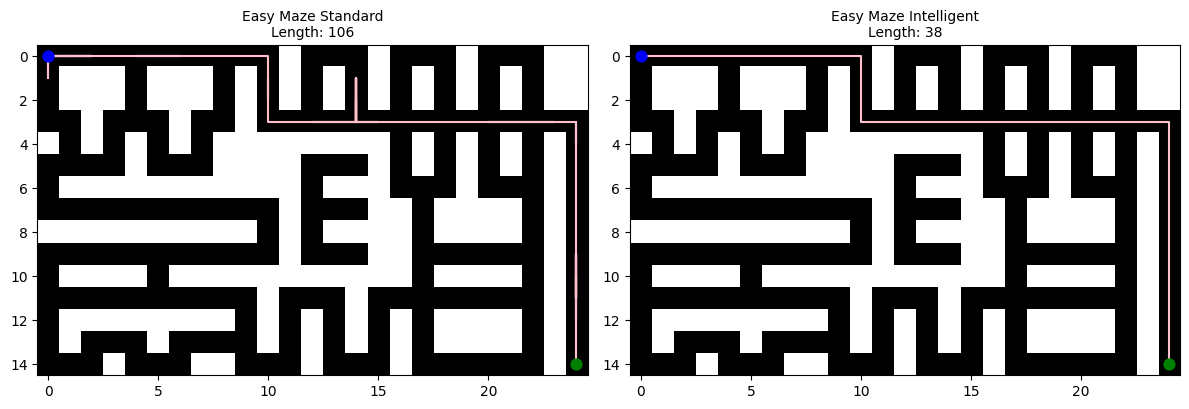

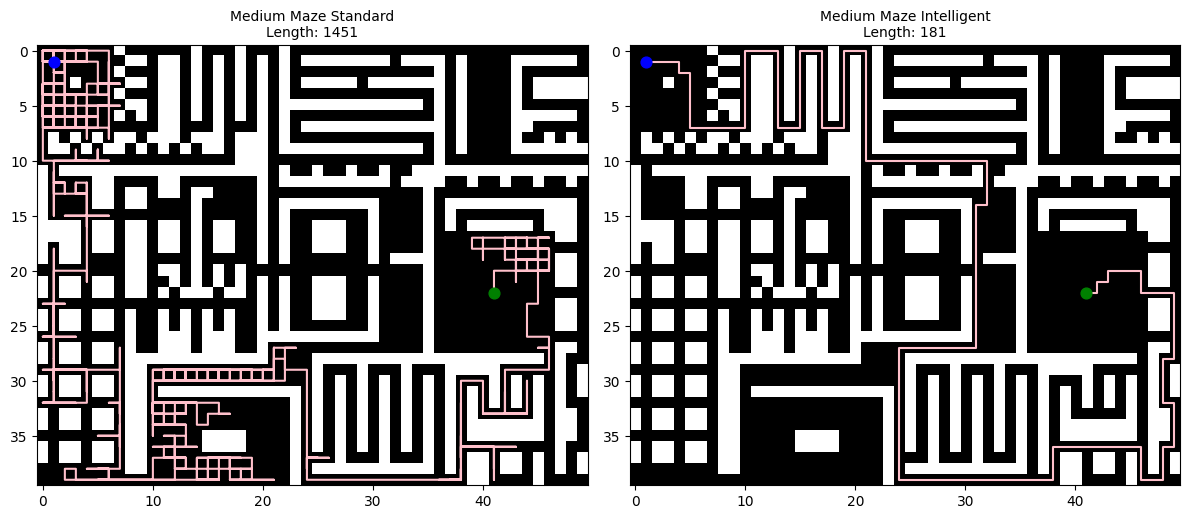

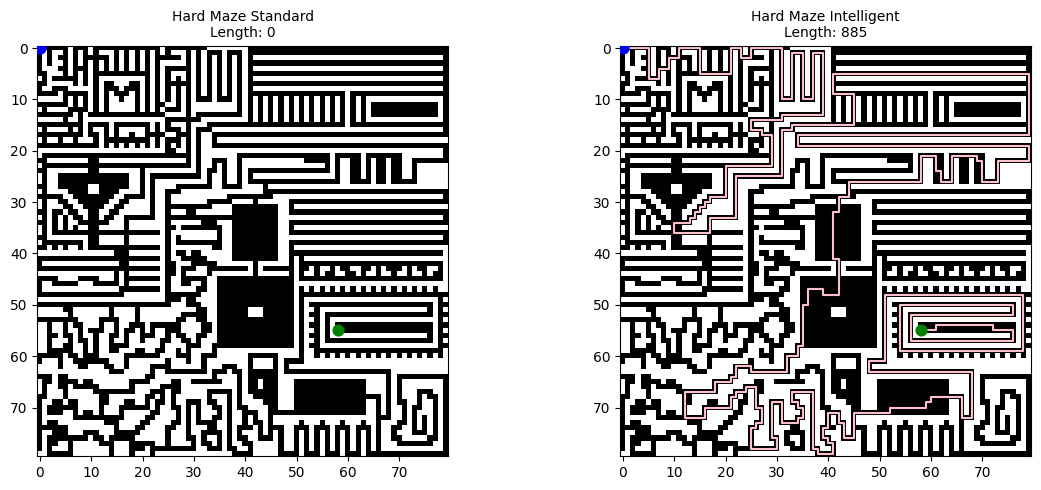

In [18]:
# Finding routes for the 3 mazes for the Intelligent implementation

# Easy Maze
m1_i, r1_i, s1_i, _ = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=True, verbose=True)

# Medium Maze
m2_i, r2_i, s2_i, _ = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=True, verbose=True)

# Hard Maze
m3_i, r3_i, s3_i, _ = run_aco('hard', 100, 300, 300, 0.1, 5000, 50, intelligent=True, verbose=True)

# maze_name, ants_per_gen, no_gen, q, evap, max_steps, convergence,

# Visualizing the improvements
visualize_side_by_side([m1, m1_i], [r1, r1_i], [s1, s1_i], ["Easy Maze Standard", "Easy Maze Intelligent"])
visualize_side_by_side([m2_route_found, m2_i], [r2_route_found, r2_i], [s2_route_found, s2_i],
                       ["Medium Maze Standard", "Medium Maze Intelligent"])
visualize_side_by_side([m3, m3_i], [r3, r3_i], [s3, s3_i], ["Hard Maze Standard", "Hard Maze Intelligent"])

Based on the side-by-side visualizations, we can clearly observe how each of the identified problems has been addressed by the Intelligent Ant's improvements:

1. **Easy Maze**
   - **Visited set (Improvement 1)** and **route pruning (Improvement 2)** completely eliminate the unnecessary loops (Problem 1) that are clearly visible in the Standard Ant's path.
   - **Path smoothing (Improvement 3)** and **direction momentum (Improvement 4)** resolve the zig-zag patterns (Problem 2), resulting in a clean, direct path from start to end.
   - Overall, the Intelligent Ant produces a dramatically shorter route compared to the Standard Ant.

2. **Medium Maze**
   - **Visited set (Improvement 1)** forces ants to explore new territory, entirely eliminating the pheromone trapping (Problem 3) seen in the Standard Ant's dense cluster of overlapping paths near the start (top-left).
   - **Best-route pheromone reinforcement (Improvement 5)** ensures that good routes are preserved across generations, accelerating convergence and allowing the Intelligent Ant to reliably find a route on the first run, whereas the Standard Ant required multiple attempts (Problem 4).
   - The improvement is even more striking than on the easy maze, highlighting how the combined improvements scale with maze complexity.

3. **Hard Maze**
   - The **combined effect of all five improvements** allows the Intelligent Ant to successfully find a valid route on the first run using the exact same parameters, while the Standard Ant failed to find any route across all `10` attempts.
   - This directly addresses Problem 4 (Failure to find routes on complex mazes), demonstrating that the Intelligent Ant's improvements are essential for solving larger, more complex mazes.

In [19]:
# Compare route lengths between Standard and Intelligent ants
for maze_name, r_std, r_int in [("Easy", r1, r1_i), ("Medium", r2_route_found, r2_i)]:
    std_len = r_std.size()
    int_len = r_int.size()
    improvement = (std_len - int_len) / std_len * 100
    print(f"{maze_name}: Standard = {std_len}, Intelligent = {int_len}, Improvement = {improvement:.1f}%")

Easy: Standard = 106, Intelligent = 38, Improvement = 64.2%
Medium: Standard = 1451, Intelligent = 181, Improvement = 87.5%


### 2.5 Parameter Optimization

#### Question 16: Your task is to find a good set of parameters for each of the grading mazes. You may do so by varying the parameters and subsequently running your algorithm. Report your approach to tuning the parameters. Assist your text with graphs showing the relationships between the parameters and the speed of convergence. Present the impact of the hyper-parameter settings on the performance with visual aids.

In [20]:
# Base parameter sets per maze
import warnings
BASE_PARAMS = {
    'easy':   dict(ants_per_gen=20,  no_gen=100, q=250,  evap=0.3, max_steps=300,  convergence=30),
    'medium': dict(ants_per_gen=50, no_gen=200, q=500, evap=0.3, max_steps=1000, convergence=40),
    'hard':   dict(ants_per_gen=100, no_gen=300, q=1000, evap=0.3, max_steps=5000, convergence=50),
}

# Values to test for each hyperparameter
SWEEP_RANGES = {
    'ants_per_gen': [5, 25, 75, 150, 300],
    'q':            [100, 300, 750, 1500, 3000],
    'evap':         [0.05, 0.1, 0.3, 0.5, 0.8],
    'max_steps':    {
        'easy':   [50, 100, 150, 250, 500],
        'medium': [300, 500, 1000, 1500, 2000],
        'hard':   [1000, 3000, 7500, 15000, 25000],
    },
    'convergence':  [10, 20, 50, 100, 200],
}

NUM_TRIALS = 3  # per hyperparameter value for easy/medium, hard uses 1 (+1 retry if no route) by default

def sweep_parameter(maze_name, param_name, param_values, base_params, num_trials=NUM_TRIALS, retry_failed_route_once=False):
    """
    Run ACO natively dynamically applying parameter sweeps inherently preserving baseline boundaries accurately.

    Args:
        maze_name (str): The name of the maze to run the sweep on.
        param_name (str): The name of the parameter to sweep.
        param_values (list): The values to test for the parameter.
        base_params (dict): The base parameters to use for the sweep.
        num_trials (int): The number of trials to run for each hyperparameter value.
        retry_failed_route_once (bool): Whether to retry a failed route once.

    Returns:
        dict: A dictionary containing the results of the sweep.
    """
    results = {}
    for idx, val in enumerate(param_values):
        params = dict(base_params)
        params[param_name] = val
        histories, lengths, times = [], [], []
        attempts = 2 if retry_failed_route_once else num_trials
        
        for trial in range(attempts):
            random.seed(SEED + idx * 1000 + trial)
            _, route, _, history = run_aco(maze_name, intelligent=True, **params)
            
            histories.append(history)
            lengths.append(route.size())
            times.append(len(history))
            
            if retry_failed_route_once and route.size() > 0:
                break
                
        results[val] = {'histories': histories, 'lengths': lengths, 'times': times}
    return results

def plot_sweep(maze_name, param_name, param_values, results, ax_conv, ax_bar, diagnostics=False, base_params=None):
    """
    Visualizes generation execution tracks dynamically applying continuous gradients mapping array results successfully.

    Args:
        maze_name (str): The name of the maze to run the sweep on.
        param_name (str): The name of the parameter to sweep.
        param_values (list): The values to test for the parameter.
        results (dict): The results of the sweep.
        ax_conv (matplotlib.axes.Axes): The axis for the convergence plot.
        ax_bar (matplotlib.axes.Axes): The axis for the bar chart.
    """
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(param_values)))

    # Plot convergence curves
    for idx, val in enumerate(param_values):
        all_h = [[np.nan if x == float('inf') else x for x in h] for h in results[val]['histories']]
        max_len = max(len(h) for h in all_h)
        padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in all_h])
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            mean_h = np.nanmean(padded, axis=0) if padded.size else []
        ax_conv.plot(range(len(mean_h)), mean_h, label=str(val), color=cmap[idx], linewidth=1.5)

    ax_conv.set(xlabel='Generation', ylabel='Best route length', title=f'{maze_name} maze - {param_name}')
    ax_conv.legend(title=param_name, fontsize=7, title_fontsize=8)
    ax_conv.grid(True, alpha=0.3)

    # Plot bar chart: best (lowest) is green, exclude zeros (failures) when determining best
    means = [np.mean(results[v]['lengths']) for v in param_values]
    stds = [np.std(results[v]['lengths']) for v in param_values]
    x_pos = range(len(param_values))
    
    valid = [m for m in means if m > 0]
    mean_min = min(valid) if valid else None
    mean_max = max(valid) if valid else 0
    r = mean_max - mean_min if mean_min is not None and len(valid) > 1 else 0
    orange_cmap = __import__('matplotlib.colors').colors.LinearSegmentedColormap.from_list('o', [(1.0, 0.9, 0.5), (1.0, 0.55, 0.1)])
    if mean_min is None or r <= 0:
        bar_colors = [orange_cmap(1.0) if m <= 0 else (0.2, 0.7, 0.2) for m in means]
    else:
        bar_colors = [(0.2, 0.7, 0.2) if m == mean_min else (orange_cmap(1.0) if m <= 0 else orange_cmap((m - mean_min) / r)) for m in means]

    ax_bar.bar(x_pos, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', linewidth=1)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels([str(v) for v in param_values], fontsize=8)
    ax_bar.set(xlabel=param_name, ylabel='Final route length', title=f'{maze_name} maze - {param_name}')

def run_all_sweeps(maze_name, sweep_ranges=SWEEP_RANGES, base_params=None, num_trials_override=None, diagnostics=False):
    """
    Executes universal hyperparameter evaluations mapping entirely explicitly across designated simulated environments intrinsically.

    Args:
        maze_name (str): The name of the maze to run the sweep on.
        sweep_ranges (dict): The ranges of values to test for each hyperparameter.
        base_params (dict): The base parameters to use for the sweep.
        num_trials_override (int): The number of trials to run for each hyperparameter value.
        diagnostics (bool): Whether to show diagnostic plots.

    Returns:
        dict: A dictionary containing the results of the sweep.
    """
    base_params = base_params or BASE_PARAMS[maze_name]
    trials = 1 if maze_name == 'hard' and num_trials_override is None else (num_trials_override or NUM_TRIALS)
    retry = maze_name == 'hard' and num_trials_override is None

    param_names = list(sweep_ranges.keys())
    fig, axes = plt.subplots(len(param_names), 2, figsize=(14, 5 * len(param_names)))
    if len(param_names) == 1: axes = axes.reshape(1, -1)

    all_results = {}
    for i, pname in enumerate(param_names):
        values = sweep_ranges[pname].get(maze_name, sweep_ranges[pname]) if isinstance(sweep_ranges[pname], dict) else sweep_ranges[pname]
        results = sweep_parameter(maze_name, pname, values, base_params, num_trials=trials, retry_failed_route_once=retry)
        all_results[pname] = (values, results)
        plot_sweep(maze_name, pname, values, results, axes[i, 0], axes[i, 1])

    fig.suptitle(f'Parameter Sweeps - {maze_name.capitalize()} Maze', fontsize=16, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()
    return all_results

RELATIVE_LENGTH_TIE = 0.03

def select_best_params(all_results, base_params, relative_length_tie=RELATIVE_LENGTH_TIE):
    """
    Identifies completely optimally configured parameters dynamically indexing multi-array results accurately efficiently effectively cleanly explicitly.

    Args:
        all_results (dict): The results of the sweep.
        base_params (dict): The base parameters to use for the sweep.
        relative_length_tie (float): The relative length tie to use for the sweep.

    Returns:
        dict: A dictionary containing the best parameters.
    """
    best = dict(base_params)
    for pname, (values, results) in all_results.items():
        candidates = [(v, float(np.mean(success))) for v in values if (success := [l for l in results[v]['lengths'] if l > 0])]
        if candidates:
            ceiling = min(m for _, m in candidates) * (1.0 + relative_length_tie)
            best[pname] = min(v for v, m in candidates if m <= ceiling)
    return best

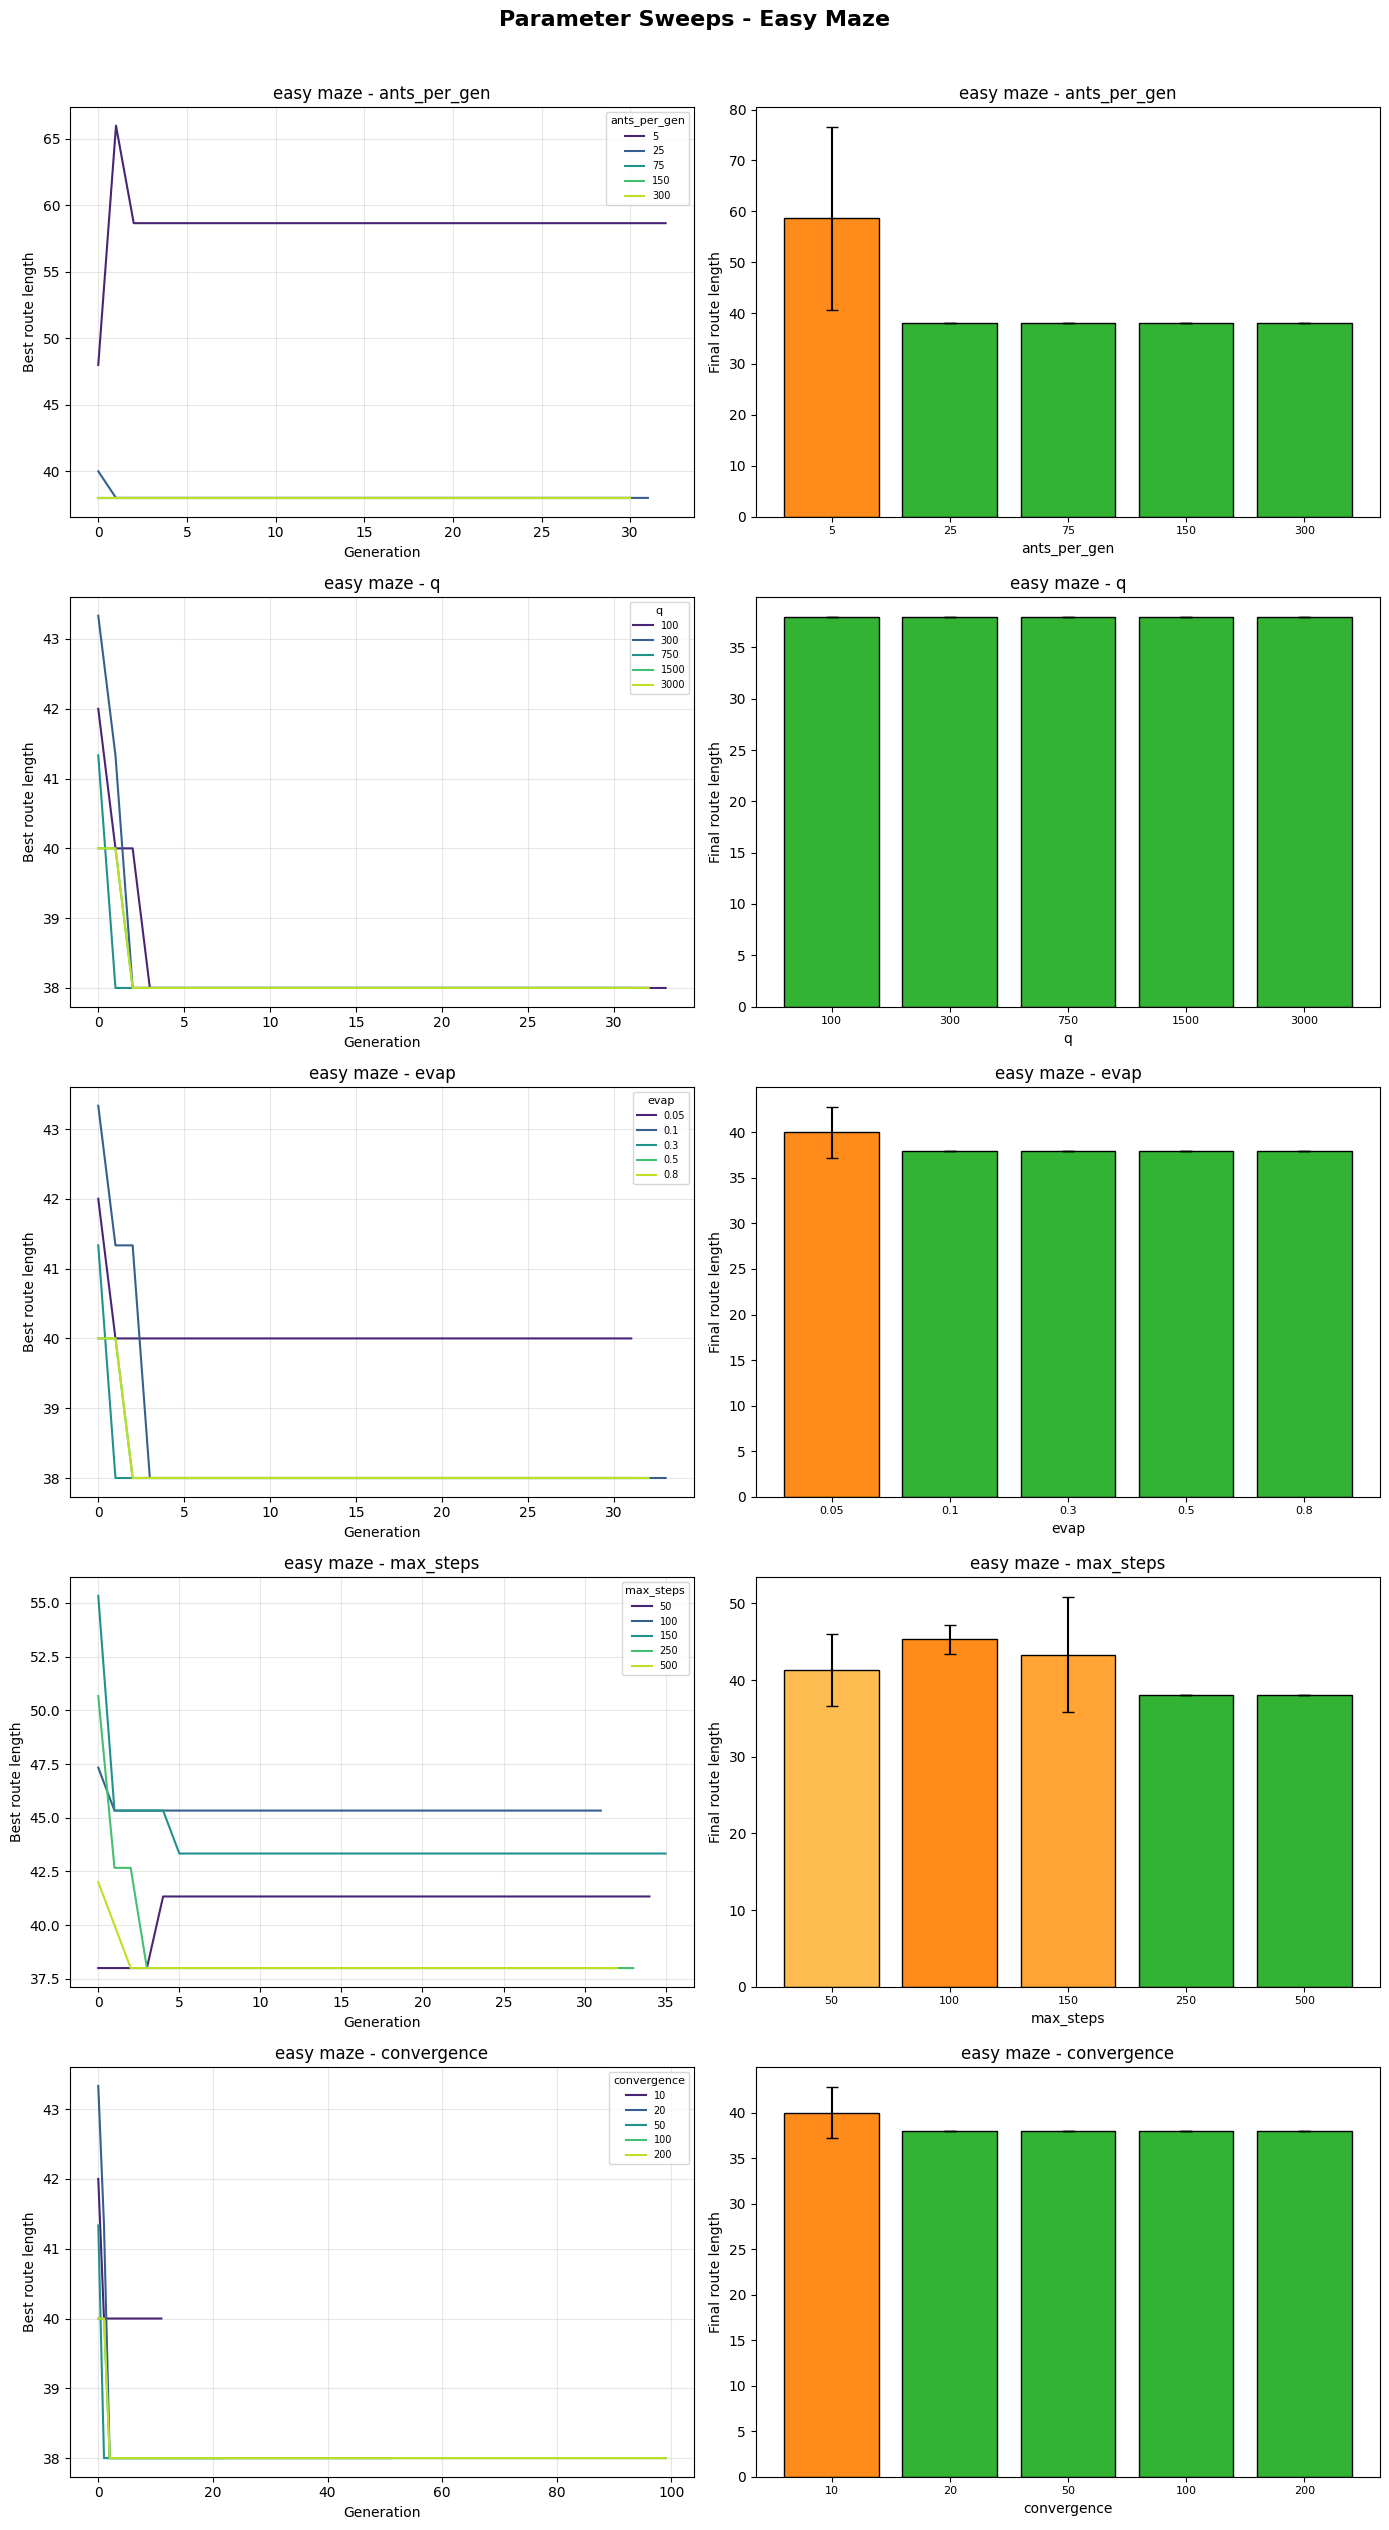

In [21]:
easy_results = run_all_sweeps('easy')

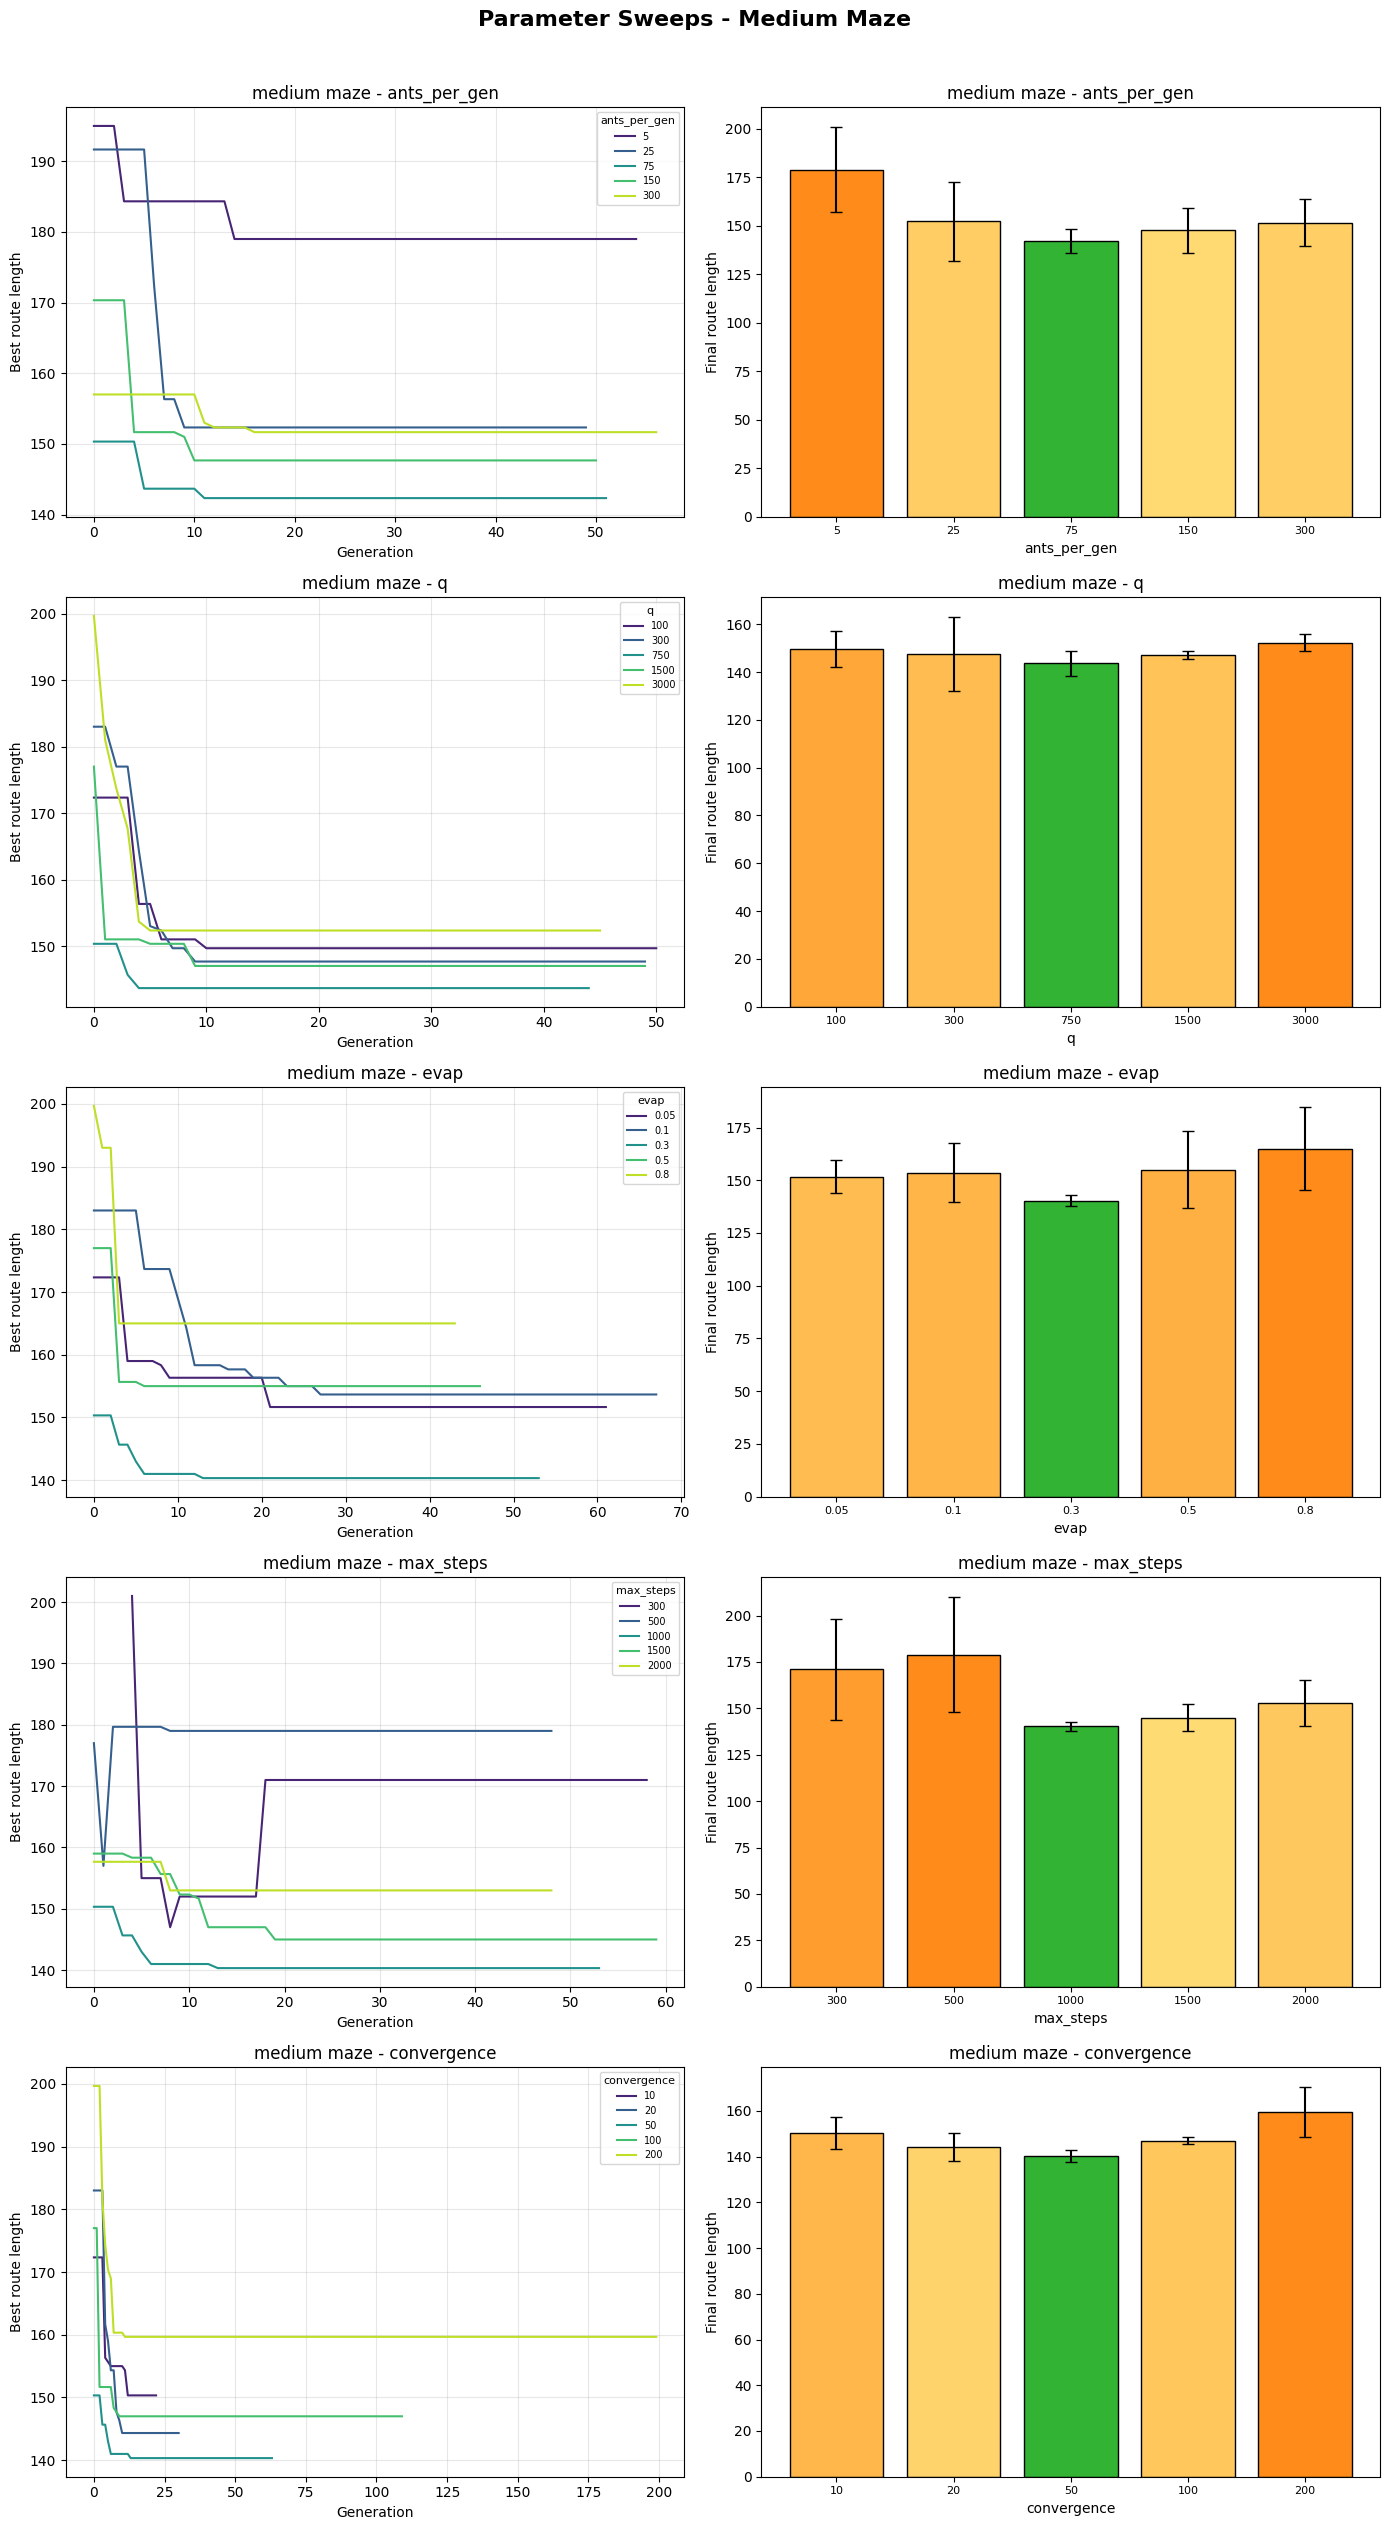

In [22]:
medium_results = run_all_sweeps('medium')

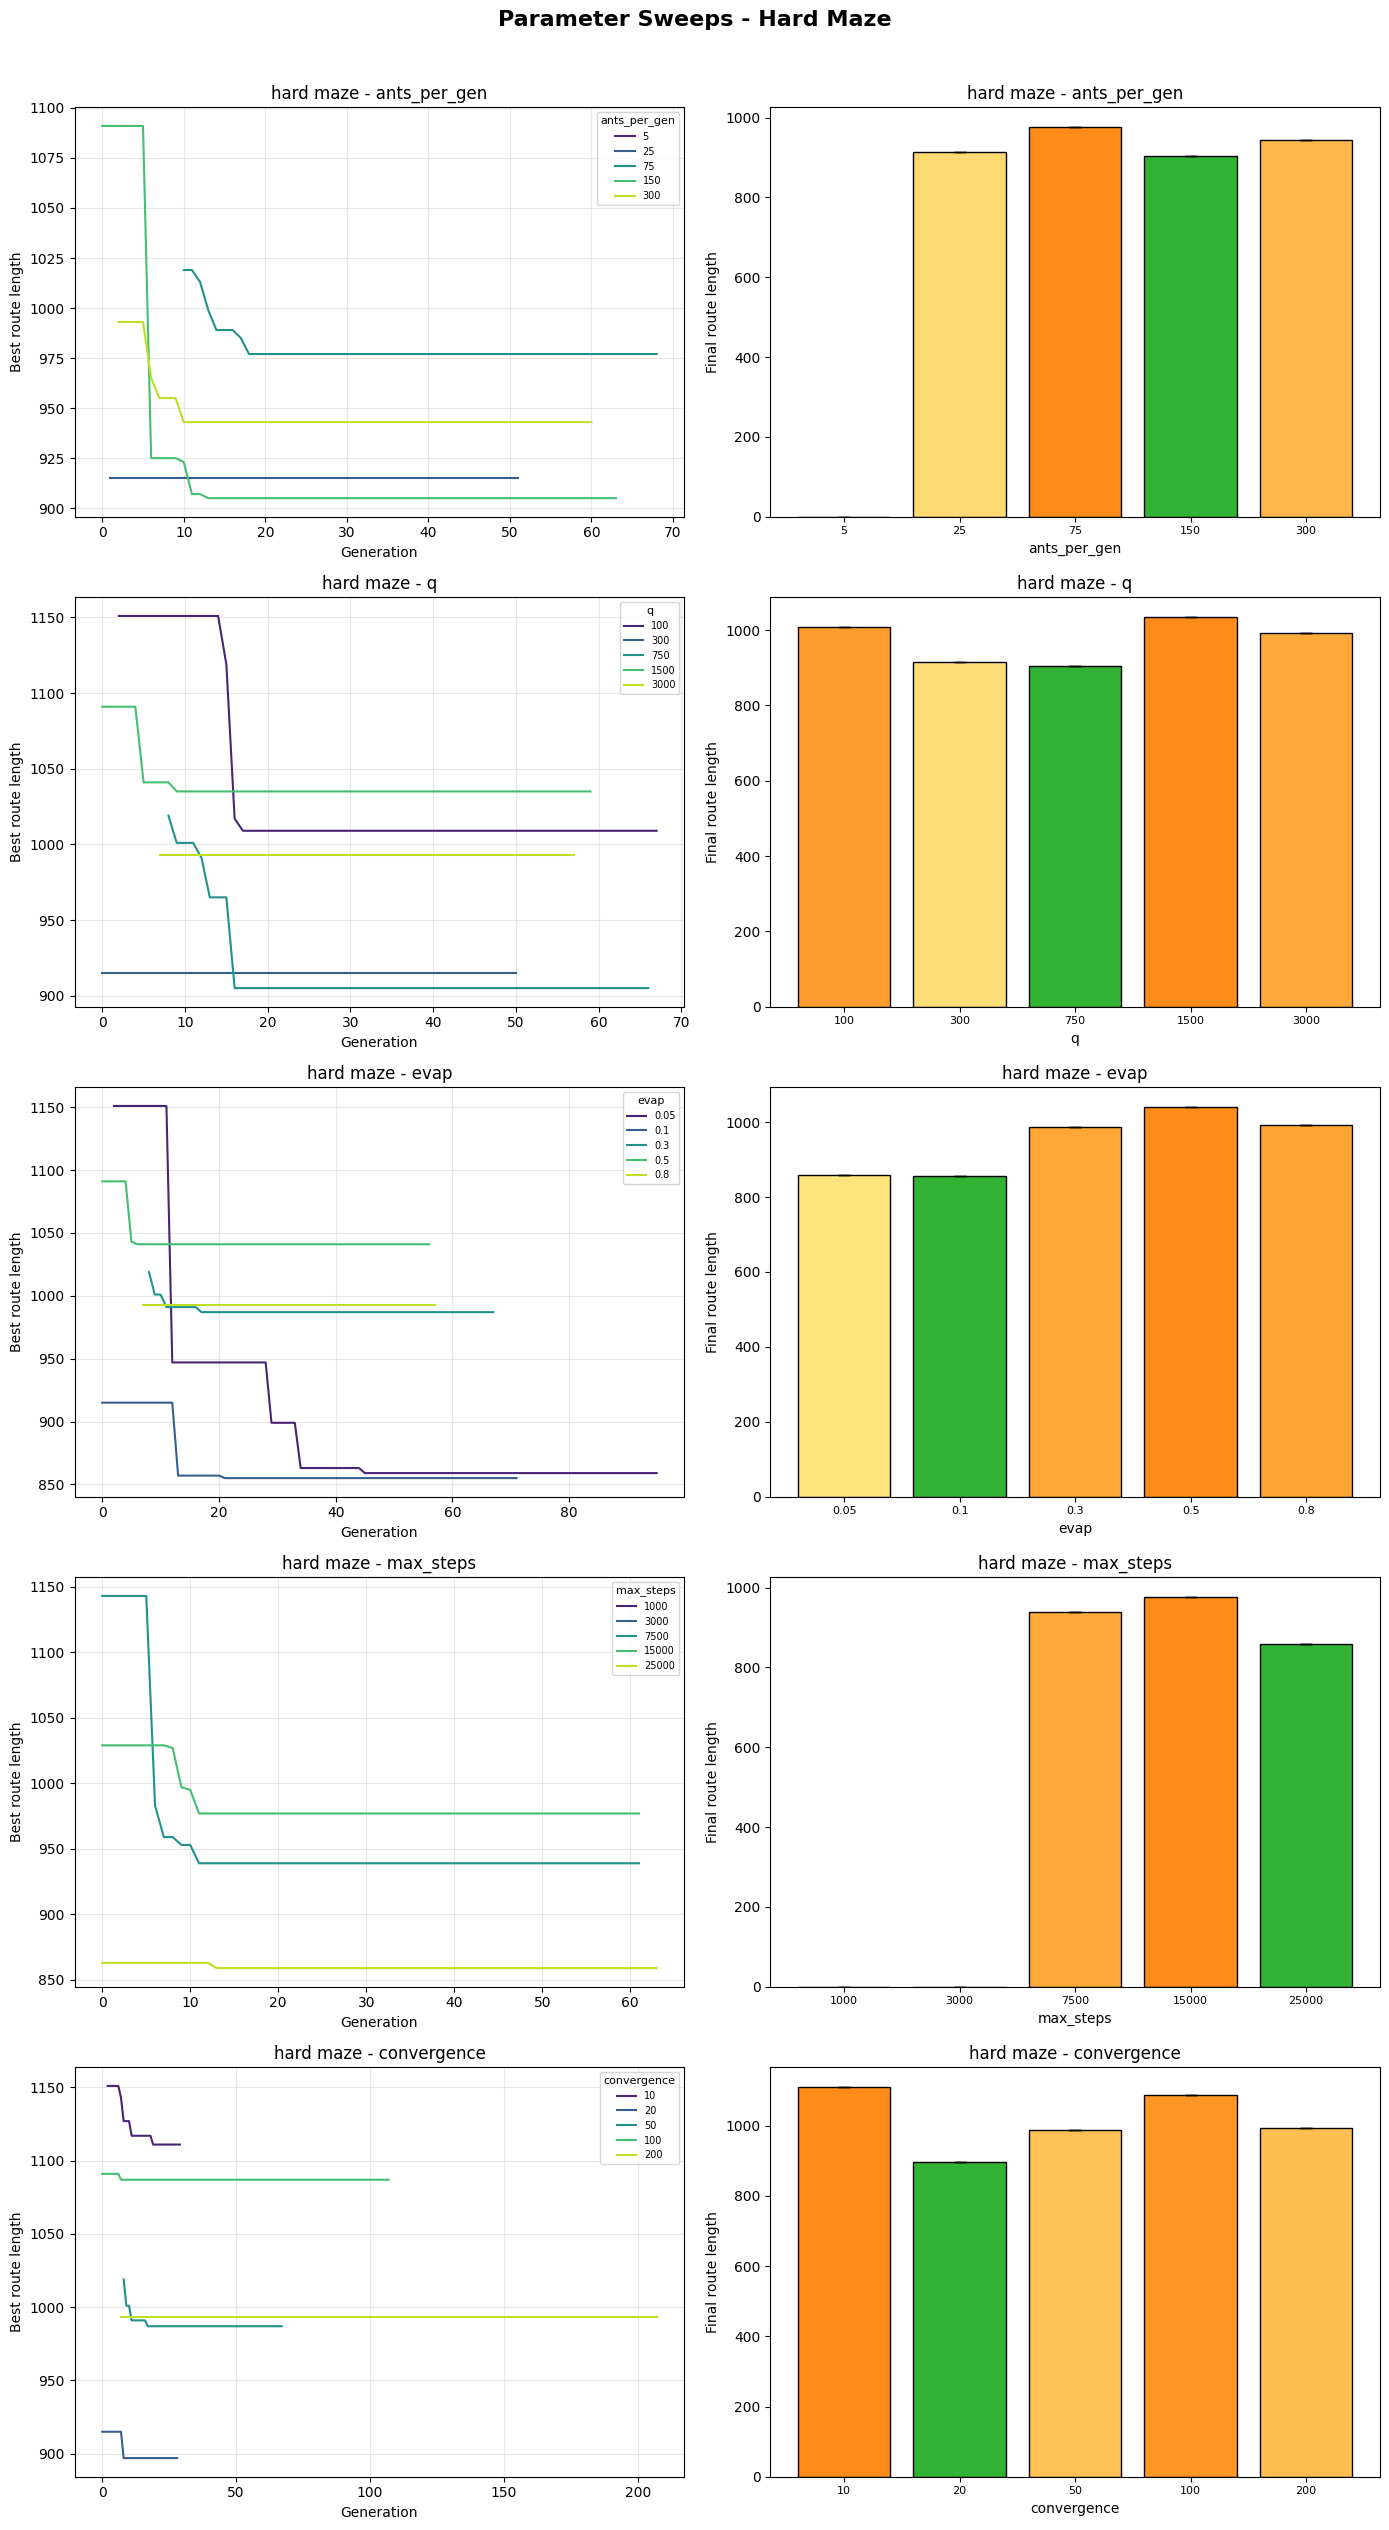

In [23]:
hard_results = run_all_sweeps('hard')

In [24]:
# select_best_params: successful runs only (length > 0). Among means within 3% of the sweep best,
# picks the smallest hyperparameter value; see RELATIVE_LENGTH_TIE in the sweep cell.
best_easy = select_best_params(easy_results,   BASE_PARAMS['easy'])
best_medium = select_best_params(medium_results, BASE_PARAMS['medium'])
best_hard = select_best_params(hard_results,   BASE_PARAMS['hard'])

# Build and display a Markdown table summarising the best params per maze
param_order = ['ants_per_gen', 'no_gen', 'q', 'evap', 'max_steps', 'convergence']
labels = {
    'ants_per_gen': 'Ants per generation',
    'no_gen': 'Max generations',
    'q': 'Q (pheromone constant)',
    'evap': 'ρ (evaporation rate)',
    'max_steps': 'Max steps per ant',
    'convergence': 'Convergence patience',
}

table = "| Parameter | Easy | Medium | Hard |\n"
table += "|-----------|:---:|:---:|:---:|\n"
for p in param_order:
    table += f"| {labels[p]} | {best_easy[p]} | {best_medium[p]} | {best_hard[p]} |\n"

display(Markdown("### Best Parameter Sets\n\n" + table))

# Verification runs with best params
trial_counts = {'easy': 3, 'medium': 2, 'hard': 1}

# Loop through mazes
for maze_name, best in [('easy', best_easy), ('medium', best_medium), ('hard', best_hard)]:
    n = trial_counts[maze_name]
    lengths = []

    # Loop through trials
    for trial in range(n):
        random.seed(SEED + trial)
        _, route, _, _ = run_aco(
            maze_name,
            best['ants_per_gen'], best['no_gen'], best['q'],
            best['evap'], best['max_steps'], best['convergence'],
            intelligent=True
        )
        lengths.append(route.size())
    # Filter out failed runs (length 0) when computing statistics
    valid = [l for l in lengths if l > 0]

### Best Parameter Sets

| Parameter | Easy | Medium | Hard |
|-----------|:---:|:---:|:---:|
| Ants per generation | 25 | 75 | 25 |
| Max generations | 100 | 200 | 300 |
| Q (pheromone constant) | 100 | 300 | 300 |
| ρ (evaporation rate) | 0.1 | 0.3 | 0.05 |
| Max steps per ant | 250 | 1000 | 25000 |
| Convergence patience | 20 | 20 | 20 |


### Tuning Strategy

We used a **one-factor-at-a-time (OFAT)** approach. For each maze, we varied one hyperparameter while holding the others at sensible base values, then selected the value that produced the shortest average route across 3 independent trials. We swept 5 parameters:
- `ants_per_gen`
- `Q`
- `evaporation`
- `max_steps`
- `convergence`

Each tested at 5 values spanning a wide range from conservatively low to aggressively high. The `IntelligentAnt` was used throughout, as it consistently outperforms the `StandardAnt` in both route quality and convergence speed.

The tables and sweep plots above report the best-found parameters for each maze. The best parameter summary table (cell output above) lists the final selected values. These were chosen as the value per parameter that minimised the average final route length over 3 trials.

We would like to briefly mentioned a limitation of the method. While the method is simple and straight forward, it is limited in complexity. The main drawback is that it ignores synergetic interactions between hyperparameter values.

Note that certain values result in a final path length of 0, that means a solution was not found.

**Impact of Hyperparameters on Performance**

1. **Ants per generation** (`ants_per_gen`)
   - On the easy maze, 5 ants performs worse, 25-300 reach similar final route lengths. On the medium maze, 75 clearly outperforms lower values. On the hard maze, 150 achieves the best result, with 25 close behind.
   - More ants improve exploration and convergence, with diminishing returns on small mazes. Larger mazes need more ants to explore and deposit useful pheromone, beyond ~300, extra ants add little benefit relative to the extra computation.

2. **Pheromone constant** (`Q`)
   - We observe that on the easy maze Q has little effect, on the medium maze 750 is best, on the hard maze 750 is best, while lower values perform worse.
   - This indicates that Q controls the strength of pheromone reinforcement relative to route length. Too low a Q yields weak reinforcement and slow convergence, too high causes early saturation and weaker discrimination between good and bad routes. A moderate range (around 100-750) tends to work across maze sizes.

3. **Evaporation rate** (`ρ`)
   - On the easy maze, 0.05 is slightly worse, 0.1 and above perform similarly. On the medium maze, 0.3 tends to perform best, on the hard maze, 0.1 yields the best result, with 0.05 close, while higher values (0.3-0.8) perform worse.
   - Evaporation is one of the most sensitive parameters. Low values keep useful trails longer but risk trapping ants in suboptimal paths, high values remove trails too quickly and reduce exploitation. The best value depends on maze complexity, with 0.05-0.3 often performing well.

4. **Maximum steps** (`max_steps`)
   - On the easy maze, 50-150 are clearly worse than 250-500. On the medium maze, 1000 is best, on the hard maze, higher values (7500-25000) generally outperform lower ones, while 1000 and 2500 fail to produce results.
   - max_steps must scale with maze size. Too few steps cause many ants to time out before reaching the goal, more steps allow more ants to complete routes and deposit pheromone. The hard maze needs substantially more steps than the easy maze.

5. **Convergence patience** (`convergence`)
   - On the easy maze, patience 10 performs worse than 20-200. On the medium maze, 50 performs best. On the hard maze, 20 performs best, higher values lead to worse results.
   - Once a good route is found, further generations often add little improvement. A low patience (e.g. 20) is usually sufficient for easy and hard, though the medium maze benefits from slightly higher patience (50).

Maze size and complexity drive the choice of hyperparameters. Small mazes are robust to most settings, larger mazes require more ants, more steps, and careful tuning of Q and evaporation. The OFAT results show that the best value for each parameter depends on the maze, and that interactions between parameters are not captured by this method.

#### Question 17: Using your answer to the previous question, how does the complexity and size of a maze influence the “optimal” value of each hyper-parameter?

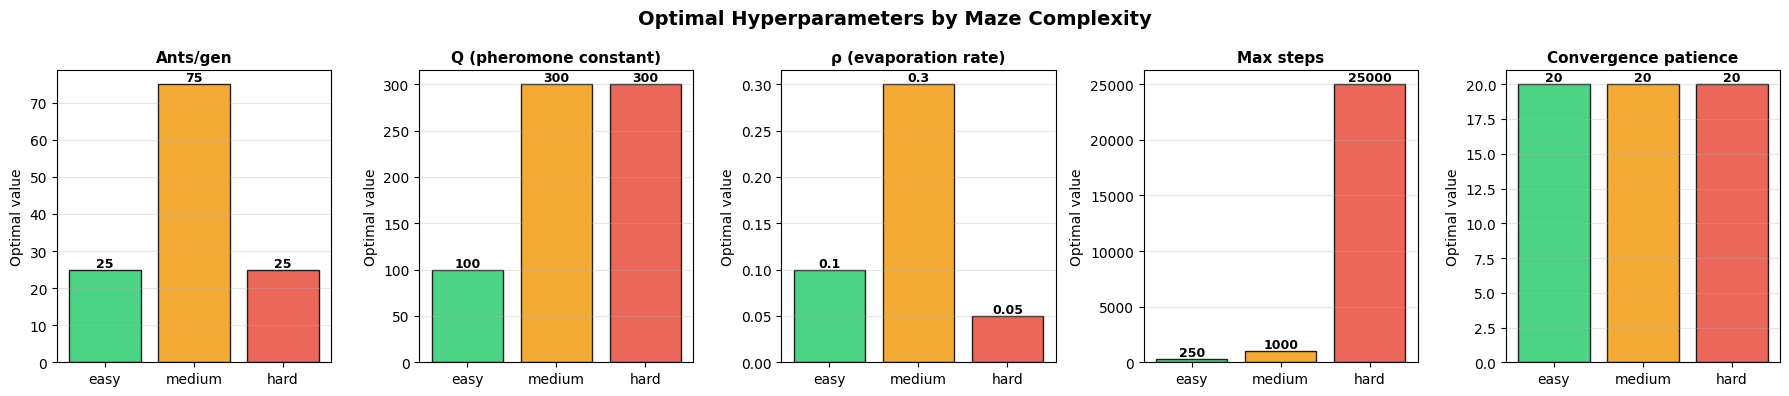

In [25]:
# Define param_order
param_order = ['ants_per_gen', 'q', 'evap', 'max_steps', 'convergence']
labels = {
    'ants_per_gen': 'Ants/gen',
    'q': 'Q (pheromone constant)',
    'evap': 'ρ (evaporation rate)',
    'max_steps': 'Max steps',
    'convergence': 'Convergence patience',
}
maze_names = ['easy', 'medium', 'hard']
best_params_list = [best_easy, best_medium, best_hard]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Loop through parameters
for idx, pname in enumerate(param_order):
    ax = axes[idx]
    values = [best[pname] for best in best_params_list]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax.bar(maze_names, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(labels[pname], fontsize=11, fontweight='bold')
    ax.set_ylabel('Optimal value')
    ax.grid(True, axis='y', alpha=0.3)

    # Loop through bars and values
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val}", ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Optimal Hyperparameters by Maze Complexity', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

The complexity and size of a maze influence the optimal value of each hyperparameter in the following ways:

1. **Ants per generation** (`ants_per_gen`): Our sweep finds optimal values of 25 for easy and hard mazes, and 75 for the medium maze. In small mazes, 25 ants provide sufficient exploration. The medium maze benefits from more ants (75) to explore its intermediate complexity, while the hard maze's optimal 25 suggests that with long route lengths and many steps, quality of exploration matters more than sheer ant count, too many ants can dilute or saturate pheromone too quickly. Too few ants in a large maze leads to sparse, noisy pheromone landscapes.

2. **Pheromone constant** (`Q`): Larger mazes require a higher Q value. Our optimal values are 100 for easy and 300 for medium and hard. Since Q is divided by route length to determine the pheromone drop per edge, longer routes (inherent to bigger mazes) would deposit negligible pheromone per cell if Q is too small. Increasing Q compensates for this, keeping the signal-to-noise ratio of the pheromone trails healthy.

3. **Evaporation rate** (`ρ`): Our sweep shows the optimal value depends on maze complexity: easy favours 0.1, medium 0.3, and the hard maze favours low evaporation (0.05). In complex mazes, it takes many generations for ants to converge, high evaporation (0.5+) erases useful trails before they can be reinforced. Low evaporation keeps promising trails longer, which helps when convergence is slow. Too low can let outdated pheromone persist, but for our hard maze the benefit of retaining trails outweighed this.

4. **Maximum steps** (`max_steps`): This must scale with maze size. Our optimal values are 250 for easy, 1,000 for medium, and 25,000 for hard. The easy maze needs at most ~250 steps, while the hard maze requires 25,000+ steps for ants to have any chance of reaching the destination. Setting this too low causes all ants to time out, setting it too high wastes computation on hopelessly lost ants (mitigated by our early termination optimization).

5. **Convergence patience** (`convergence`): Our sweep finds 20 to be optimal across all maze complexities. Once a good route is found, further generations often add little improvement. A patience of 20 generations is sufficient for stopping, though noisier or very complex mazes may occasionally benefit from slightly higher patience.

In summary, maze complexity and size push `Q` and `max_steps` upward, higher pheromone constant and more steps for larger mazes, while `ants_per_gen` peaks at 75 for medium and stays at 25 for easy and hard. Evaporation varies by maze: low (0.05) for complex mazes where trails need time to accumulate, moderate (0.1-0.3) for easier ones. Convergence patience remains constant at 20 across all complexities.

### 2.6 The Final Route

#### Question 18: Run your code using your decent set of parameters on each of the grading mazes. Output your route as described in the Route Syntax section (you can verify the correctness by opening your route in the visualizer). See also “Deliverables” in Section 0.

In [26]:
GROUP = 61
NUM_TRIALS = 1  # Run each maze multiple times, used for testing

q18_mazes, q18_routes, q18_specs, q18_titles = [], [], [], []

# Loop through mazes
for maze_name, best in [('easy', best_easy), ('medium', best_medium), ('hard', best_hard)]:
    best_route = None
    best_maze = None
    best_spec = None

    # Loop through trials
    for trial in range(NUM_TRIALS):
        random.seed(SEED + trial)
        maze, route, spec, _ = run_aco(
            maze_name,
            best['ants_per_gen'], best['no_gen'], best['q'],
            best['evap'], best['max_steps'], best['convergence'],
            intelligent=True, verbose=False
        )
        if best_route is None or route.size() < best_route.size():
            best_route = route
            best_maze = maze
            best_spec = spec

    out_path = f"./../data/{GROUP}_{maze_name}.txt"
    best_route.write_to_file(out_path)

    q18_mazes.append(best_maze)
    q18_routes.append(best_route)
    q18_specs.append(best_spec)
    q18_titles.append(f"{maze_name.capitalize()} maze")

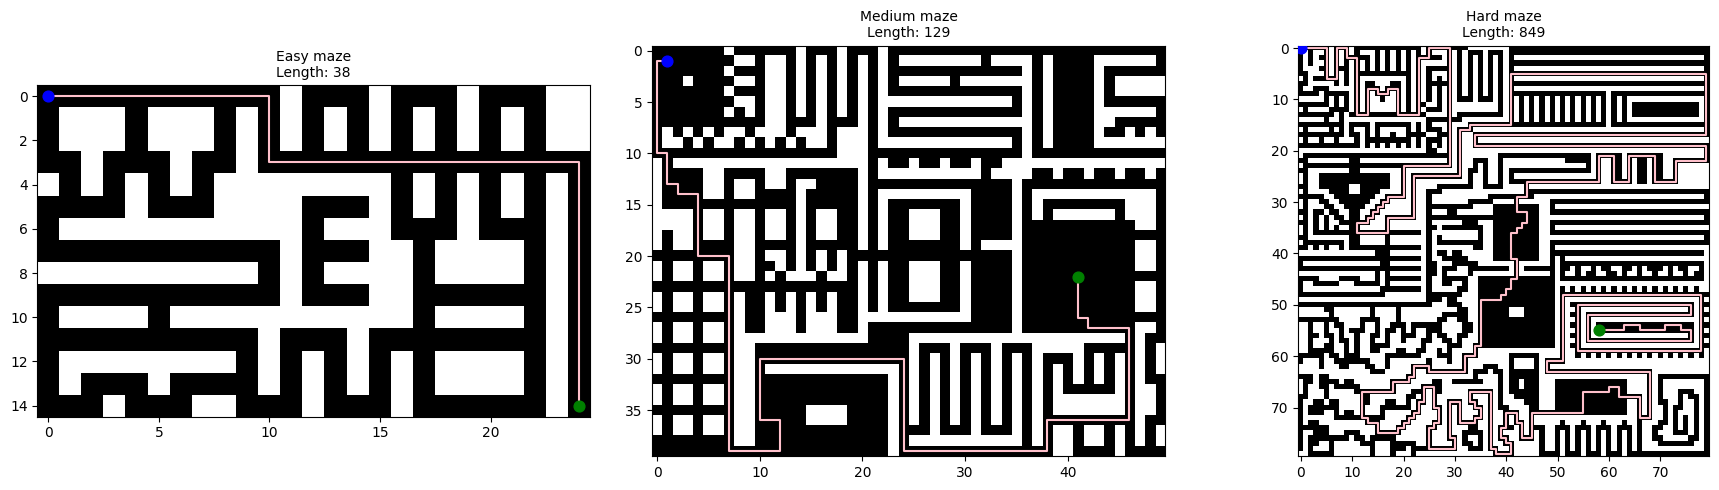

In [27]:
# Visualize the final routes for the three grading mazes
visualize_side_by_side(q18_mazes, q18_routes, q18_specs, q18_titles)

### 2.7 Synthesis

#### Question 19: What are the differences (length, order of items, etc.) between the current path and the path found by your algorithmin Part 1? Which solution is better? Why?

In [28]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 50
no_gen = 100
q = 1000
evap = 0.1
max_steps = 10000
convergence = 50

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, convergence)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution, _, _ = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/61_actions_TSP.txt")

Ready reading maze file ./../data/hard_maze.txt
True


The **current path** (Part 1) uses the provided `optimal_tsp` file with exact pairwise distances and yields a tour length of **1325**. The path from Part 2.7 uses distances estimated by our ACO algorithm on the hard maze, then runs the GA on that distance matrix.

**Differences**

1. **Length:** The Part 1 tour has length 1325 and matches the Held-Karp optimum. The Part 2.7 tour length depends on the ACO estimates, it can be longer or shorter than 1325, but “shorter” would be misleading because it is measured on noisy distances, not on the true maze distances.

2. **Order of items:** The visit order can differ. The GA in Part 1 optimizes over exact distances, so its order is optimal for that matrix. In Part 2.7, the GA optimizes over ACO-estimated distances, which may be biased or inconsistent, so the order can change.

3. **Distance matrix:** Part 1 uses a given, symmetric distance matrix. Part 2.7 uses our ACO-based matrix, which can be asymmetric and noisy, especially with few ACO iterations.

**Which solution is better? Why?**

The **Part 1 solution is better**. It uses exact pairwise distances, so the GA optimizes the true objective and the tour length 1325 is meaningful. The Part 2.7 solution optimizes over ACO-estimated distances, which are approximations. With limited ACO runs (e.g. few generations and ants), these estimates can be poor, so a “shorter” tour in Part 2.7 may not correspond to a shorter real path in the maze. For a fair comparison, we would need more ACO iterations and tuning so that the distance matrix is reliable before re-running the GA.

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20: Genetic algorithms need a fitness function, but there are many scenarios where you will not know the correct (underlying) fitness function. Discuss an example where this would be the case. How can it cause problems?

A scenario where the correct underlying fitness function is not known is when the problem is to make a robot walk as fast and smoothly as possible. Since it depends on multiple complex factors, such as balance, joint dynamics, friction and terrain, there is no simple mathematical function that captures all these factors accurately.

As a result, the genetic algorithm can face several problems. First, fitness evaluations may be miselading due to small measurement errors, leading to increasing or decreasing the quality of a candidate. Second, the algorithm might be guided towards a solution that is optimal under the measured fitness, but far from the true global optimum. Finally, the fitness function may only capture a part of the desired behaviour, e.g. it captures the speed, but not the stability, and thus the algorithm could evolve the solutions that maximise the fitness score while performing badly in real-world conditions.

#### Question 21: What about “survival functions”? Do we always want the strongest individual to survive? How can we mitigate these problems through the mechanisms of selection?

We do not want to the strongest individual to survive, since its genes would dominate the population too quickly. This would result in the algorithm converging "prematurely", where all individuals become almost identical and the algorithm stops exploring new possibilities. This algorithm would find a good solution, but not the best, like the goal of a genetic algorithm.

To mitigate these problems to ensure there is a good combination of strength and diversity in the group, the following can be introduced:
1. **Tournament Selection**:  Instead of picking the best overall individual, a subset of the population is chosen and the best within that group is picked. This allows smaller-fitness individuals a chance to breed.
2. **Elitism**: The best individuals are copied to the next generation without modification, ensuring that the best solution is never lost, while allowing the rest of the population to explore.
3. **Mutation**: Mutations keep the population diverse, ensuring that the search does not get stuck in a local optimum. 

### 3.2 Pen and Paper

#### Question 22

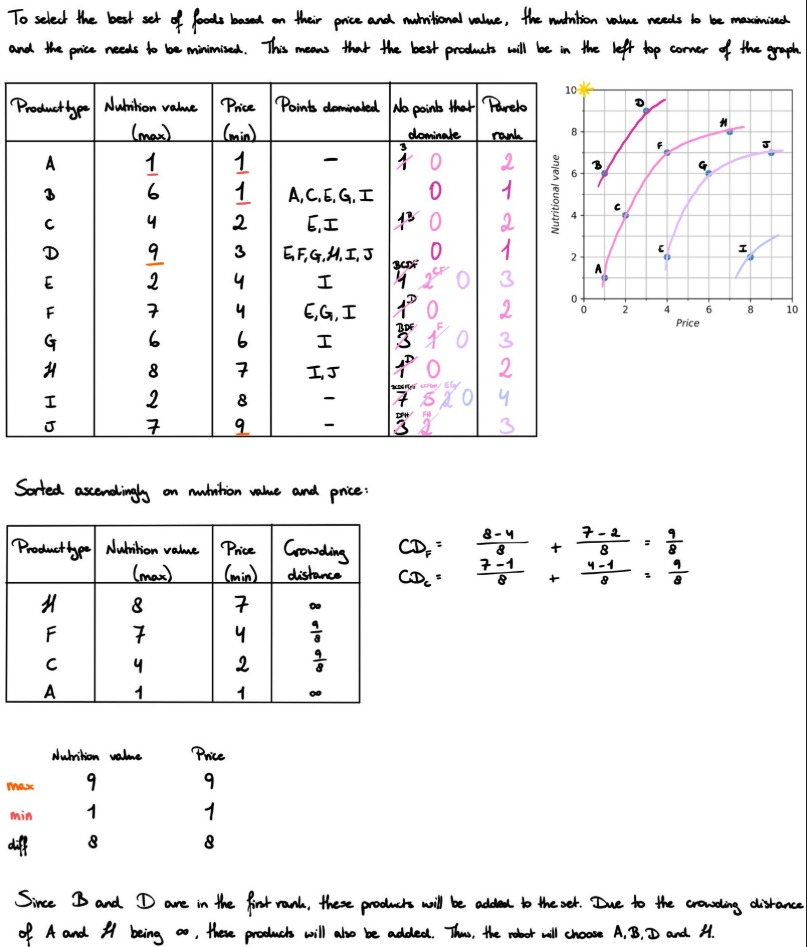

### 3.3 Division of Work

#### Question 23

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

Generative AI was used for help with the following:
- **Markdown**: for example, making tables in Markdown
- The Held-Karp verification helper (mentioned in the code)
- Assistance with debugging and writing unit tests
- Suggestions (mentioned in the code) and verification that the code is correct
- Assistance for refinement of plots via `matplotlib`
- Used for assistance with documentation such as comments and docstrings